In [1]:
import sys
from pathlib import Path
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from src.utils.paths import load_paths
paths = load_paths()


## 0. Imports and code config

In [2]:
# === 0) Imports & core config ===
# !pip install -q pybioclip scikit-learn pandas numpy pillow torch

import json, random, hashlib, os, time
from pathlib import Path
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import torch

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# BioCLIP: used as a feature extractor (image -> embedding vector)
from bioclip.predict import BaseClassifier

# ---- View mode --------------------------------------------------------------
# Which view(s) to feed into the SVM:
#   "both"    -> final_data_cleaned.json; specimen vec = mean(dorsal, ventral)
#                (original behavior — requires both views per specimen)
#   "dorsal"  -> dorsal_only_data.json;   specimen vec = dorsal embedding only
#   "ventral" -> ventral_only_data.json;  specimen vec = ventral embedding only
# VIEW_MODE is appended to the run-dir name (e.g., runs/260517_120000_dorsal)
# so the three modes never overwrite each other and can be compared later.
VIEW_MODE = "dorsal"

_VIEW_JSON = {
    "both": "final_data_cleaned.json",
    "dorsal": "dorsal_only_data.json",
    "ventral": "ventral_only_data.json",
}
assert VIEW_MODE in _VIEW_JSON, f"VIEW_MODE must be one of {list(_VIEW_JSON)}"

# ---- paths (adjust these if needed) ----
CLASS_NAMES = paths['processed_dir'] / 'class_names_cleaned.json'   # species list
DATA        = paths['processed_dir'] / _VIEW_JSON[VIEW_MODE]        # records: image_path, true_label, sample_id, view

# ---- experiment knobs (global conventions we agreed) ----
SHOTS      = [1, 3, 5, 10, 25, 35]   # K values to sweep
RUNS       = 100             # number of Monte Carlo runs per shots level
BASE_SEED  = 42              # base for deterministic seed derivation
BAND       = "sd"            # "sd"
MIN_TOTAL  = 50              # species must have >=50 individuals

# ---- results locations ----
# Base results directory from config
SVM_RESULTS = paths.get('svm_results_dir', paths['results_dir'] / 'svm')
if isinstance(SVM_RESULTS, str):
    SVM_RESULTS = paths['results_dir'].parent / SVM_RESULTS
SVM_RESULTS.mkdir(parents=True, exist_ok=True)

# Each run gets a timestamped + view-tagged folder: results/svm/runs/YYMMDD_HHMMSS_<mode>/
RUN_ID = datetime.now().strftime("%y%m%d_%H%M%S") + f"_{VIEW_MODE}"
RUN_DIR = SVM_RESULTS / "runs" / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Outputs for this run
PREDICTIONS_CSV = RUN_DIR / "predictions.csv"
PLOTS_DIR = RUN_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR = RUN_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Aggregated results (across all runs) go in results/svm/aggregated/
AGGREGATED_DIR = SVM_RESULTS / "aggregated"
AGGREGATED_DIR.mkdir(parents=True, exist_ok=True)

# ---- preview/save controls (you can flip these later) ----
PREVIEW_PLOTS = True   # show plots inline while iterating
SAVE_PLOTS    = True   # save PNGs to PLOTS_DIR

# ---- per-image embedding cache (under data/processed/) ----
EMB_CACHE = paths['emb_cache_dir']
EMB_CACHE.mkdir(parents=True, exist_ok=True)

# ---- device + model init ----
# DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")  # uncomment for Mac
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BC = BaseClassifier(device=DEVICE)

# ---- helpers ----
def seed_for(shots: int, run_id: int, base: int = BASE_SEED) -> int:
    """
    Independent few-shot: unique seed per (shots K, run_id).
    Prevents 'growing' the same cohort across K.
    """
    return int(base + 10_000 * shots + run_id)

# optional: fix global RNGs for any non-swept randomness
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)

# canonical class order placeholder (set after Block 1 once we know retained species)
CLASS_ORDER = None

# ---- run-time banner ----
print("=" * 60)
print(f"SVM Few-Shot Classification Pipeline  [VIEW_MODE={VIEW_MODE}]")
print("=" * 60)
print(f"Data JSON:        {DATA.name}")
print(f"Run ID:           {RUN_ID}")
print(f"Run directory:    {RUN_DIR.resolve()}")
print(f"Predictions CSV:  {PREDICTIONS_CSV.resolve()}")
print(f"Plots dir:        {PLOTS_DIR.resolve()}")
print(f"Analysis dir:     {ANALYSIS_DIR.resolve()}")
print(f"Embedding cache:  {EMB_CACHE.resolve()}")
print(f"Device:           {DEVICE}")
print(f"Config -> SHOTS: {SHOTS} | RUNS: {RUNS} | MIN_TOTAL: {MIN_TOTAL}")
print("=" * 60)


SVM Few-Shot Classification Pipeline  [VIEW_MODE=dorsal]
Data JSON:        dorsal_only_data.json
Run ID:           260518_000631_dorsal
Run directory:    /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal
Predictions CSV:  /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/predictions.csv
Plots dir:        /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots
Analysis dir:     /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/analysis
Embedding cache:  /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/data/processed/emb_cache
Device:           cuda
Config -> SHOTS: [1, 3, 5, 10, 25, 35] | RUNS: 100 | MIN_TOTAL: 50


## 1. Load classes and Specimens

In [3]:
# === Block 1 — Load Classes and Data → Build Specimen Index (clean version) ===

# 1) Load class list and data
with open(CLASS_NAMES, "r") as f:
    SPECIES_LIST = set(json.load(f))

with open(DATA, "r") as f:
    data = json.load(f)  # list of records (image_path, true_label, sample_id, view)

# 2) Build specimen index:
#    by_species[species][sample_id] -> {"dorsal": <path>, "ventral": <path>}
#    For VIEW_MODE="dorsal"/"ventral" the JSON contains only that view,
#    so each specimen entry ends up with just one of the two keys.
by_species = defaultdict(lambda: defaultdict(dict))
for r in data:
    sp = r["true_label"]
    if sp not in SPECIES_LIST:
        continue
    sid  = r["sample_id"]
    view = str(r["view"]).strip().lower()
    by_species[sp][sid][view] = r["image_path"]

# 3) View-mode-aware specimen filter:
#    - "both"    keep specimens that have BOTH dorsal AND ventral
#    - "dorsal"  keep specimens that have at least the dorsal view
#    - "ventral" keep specimens that have at least the ventral view
REQUIRED_VIEWS = {
    "both":    {"dorsal", "ventral"},
    "dorsal":  {"dorsal"},
    "ventral": {"ventral"},
}[VIEW_MODE]

for sp in list(by_species.keys()):
    for sid in list(by_species[sp].keys()):
        views = by_species[sp][sid]
        if not REQUIRED_VIEWS.issubset(views.keys()):
            del by_species[sp][sid]
    if not by_species[sp]:
        del by_species[sp]

# 4) Enforce ≥ MIN_TOTAL individuals per species
for sp in list(by_species.keys()):
    if len(by_species[sp]) < MIN_TOTAL:
        del by_species[sp]

included_species = sorted(by_species.keys())

# 5) Set canonical class order sorted by descending N (total specimens per species)
SPECIES_N = {sp: len(by_species[sp]) for sp in included_species}
CLASS_ORDER = sorted(included_species, key=lambda sp: SPECIES_N[sp], reverse=True)

# 6) Print summary
n_specimens = sum(len(smap) for smap in by_species.values())
print(f"[VIEW_MODE={VIEW_MODE}] required views: {sorted(REQUIRED_VIEWS)}")
print(f"Included species: {len(included_species)}")
print(f"Total usable specimens (≥ {MIN_TOTAL} per species): {n_specimens}")
for sp in CLASS_ORDER:
    print(f"  {sp}: {SPECIES_N[sp]} specimens")

assert len(included_species) > 0, "No species meet the criteria (views and MIN_TOTAL)."
print("CLASS_ORDER set for downstream use:", CLASS_ORDER)


[VIEW_MODE=dorsal] required views: ['dorsal']
Included species: 5
Total usable specimens (≥ 50 per species): 721
  Dermacentor variabilis: 318 specimens
  Ixodes scapularis: 174 specimens
  Amblyomma americanum: 124 specimens
  Haemaphysalis leporispalustris: 53 specimens
  Haemaphysalis longicornis: 52 specimens
CLASS_ORDER set for downstream use: ['Dermacentor variabilis', 'Ixodes scapularis', 'Amblyomma americanum', 'Haemaphysalis leporispalustris', 'Haemaphysalis longicornis']


## Block 2 Train test split

In [4]:
# === Block 2 — Train/Test Split (shots-aware, Seeded, prints) ===
def split_for_run(by_species, species_list, k, run_id):
    """Independent split for this (K=k, run_id) using the new seed_for()."""
    seed = seed_for(k, run_id)         # <- uses your new Block-0 seed_for
    return split_once(by_species, species_list, k=k, seed=seed)

def split_once(by_species, species_list, k, seed):
    rng = random.Random(seed)
    train_pairs, test_pairs = [], []
    per_species_counts = {}

    for sp in species_list:
        sids = list(by_species[sp].keys())
        rng.shuffle(sids)
        tr, te = sids[:k], sids[k:]

        # Sanity checks per your policy
        assert len(tr) == k, f"{sp}: needs exactly {k} train specimens, found {len(tr)}"
        assert len(te) >= 1, f"{sp}: needs at least 1 test specimen (has {len(sids)} total)"

        train_pairs.extend([(sp, sid) for sid in tr])
        test_pairs.extend([(sp, sid) for sid in te])
        per_species_counts[sp] = {"train": len(tr), "test": len(te), "total": len(sids)}

    # No leakage: specimen (sample_id) cannot be in both sets
    assert not (set(train_pairs) & set(test_pairs)), "Leakage detected: same (species, sample_id) in train & test"

    n_test_run = len(test_pairs)
    return train_pairs, test_pairs, per_species_counts, n_test_run


# --- Example single-run preview (keep this pattern for ad-hoc checks) ---
K_demo    = 5          # can use 1 / 3 / 10 too
RUN_demo  = 0          # change this to see different runs at same K

train_pairs, test_pairs, split_counts, n_test_run = split_for_run(
    by_species, included_species, k=K_demo, run_id=RUN_demo
)

# ---- Summary prints (unchanged style) ----
n_species = len(included_species)
n_train   = len(train_pairs)
n_test    = len(test_pairs)

print(f"(K, run) = ({K_demo}, {RUN_demo}) | seed = {seed_for(K_demo, RUN_demo)}")
print(f"Species included: {n_species}")
print(f"Train specimens: {n_train}  (expected {K_demo} × {n_species} = {K_demo*n_species})")
print(f"Test specimens:  {n_test}")

for sp in included_species:
    c = split_counts[sp]
    print(f"  {sp}: total={c['total']}, train={c['train']}, test={c['test']}")

# Optional: peek a few chosen IDs per species
for sp in included_species:
    chosen = [sid for (s, sid) in train_pairs if s == sp][:min(3, K_demo)]
    print(f"  Train IDs sample — {sp}: {chosen}")

(K, run) = (5, 0) | seed = 50042
Species included: 5
Train specimens: 25  (expected 5 × 5 = 25)
Test specimens:  696
  Amblyomma americanum: total=124, train=5, test=119
  Dermacentor variabilis: total=318, train=5, test=313
  Haemaphysalis leporispalustris: total=53, train=5, test=48
  Haemaphysalis longicornis: total=52, train=5, test=47
  Ixodes scapularis: total=174, train=5, test=169
  Train IDs sample — Amblyomma americanum: ['ZOE-0014-01', '50-02', 'T14621']
  Train IDs sample — Dermacentor variabilis: ['225-01', '129-01', '126-01']
  Train IDs sample — Haemaphysalis leporispalustris: ['T10154', 'T17514', 'T10136']
  Train IDs sample — Haemaphysalis longicornis: ['62-03', 'T19381', 'T19389']
  Train IDs sample — Ixodes scapularis: ['619-01', '49-04', '339-01']


## Block 3: Embedding helpers, getting the embeddings and building our Cache. 

building a mean of the dorsal and ventral embeddings

In [5]:
# === Block 3 — Embedding Helpers (Per-Image Cache + Specimen Vector) ===

# Per-image cache filename (hash of the image path -> unique + reproducible)
def _cache_fp(img_path: str) -> Path:
    h = hashlib.sha256(img_path.encode("utf-8")).hexdigest()[:24]
    return EMB_CACHE / f"{h}.npy"

# Single-image -> embedding (uses cache if available)
def embed_image(img_path: str) -> np.ndarray:
    """
    Input:  path to an image file
    Output: 1D numpy array (BioCLIP embedding), L2-normalized if normalize=True in create_image_features
    """
    fp = _cache_fp(img_path)
    if fp.exists():
        return np.load(fp)
    pil = Image.open(img_path).convert("RGB")
    vec = BC.create_image_features([pil], normalize=True).cpu().numpy()[0]
    np.save(fp, vec)
    return vec

# Specimen-level vector: average whatever views are present
def specimen_vec(rec: dict) -> np.ndarray:
    """
    rec is a dict of view -> image path, e.g. {"dorsal": ...} or {"dorsal":..., "ventral":...}.
    VIEW_MODE="both"    -> rec has both views, returns 0.5*(z_dorsal + z_ventral)
    VIEW_MODE="dorsal"  -> rec has only "dorsal", returns z_dorsal
    VIEW_MODE="ventral" -> rec has only "ventral", returns z_ventral
    Implemented generically by averaging the embeddings of whatever views are present,
    which collapses to the single embedding when only one view is in `rec`.
    """
    vecs = [embed_image(p) for p in rec.values()]
    return np.mean(vecs, axis=0)


## Block 4- build X/Y, Train SVM, Metrics, SINGLE SEED

In [6]:
# === Block 4 — Build X/y, Train SVM, Predict, Collect Rows (per run) ===

# helper: turn (species, sample_id) pairs into X (embeddings) and y (labels)
def build_xy(by_species, pairs):
    X, y, ids = [], [], []
    for sp, sid in pairs:
        rec = by_species[sp][sid]          # {"dorsal":..., "ventral":...}
        X.append(specimen_vec(rec))        # averaged dorsal+ventral embedding
        y.append(sp)                       # species label
        ids.append(sid)                    # specimen ID for reporting
    return np.stack(X), np.array(y), ids


def train_predict_collect(by_species,
                          train_pairs, test_pairs,
                          *,
                          shots: int, run_id: int, n_test_run: int):
    """
    Trains the SVM on the given split and collects per-specimen rows for master CSV.
    Returns:
      pred_rows       : list[dict]  (rows for master_predictions.csv)
      per_class_df    : DataFrame  (class_acc, n_test_class)
      macro_acc       : float
      overall_acc     : float
      y_true, y_pred  : np.ndarray, np.ndarray  (for confusion / preview plots)
    """

    # --- Derive the run-specific seed HERE to guarantee independence
    seed = seed_for(shots, run_id)

    # --- Build train/test matrices
    Xtr, ytr, _      = build_xy(by_species, train_pairs)
    Xte, yte, te_ids = build_xy(by_species, test_pairs)

    # --- SVM pipeline (scale → RBF SVM); probability=True to get confidence
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=seed))
    ])

    # --- Train + predict
    clf.fit(Xtr, ytr)
    yhat  = clf.predict(Xte)
    probs = clf.predict_proba(Xte)
    conf  = probs.max(axis=1)   # top-class probability per specimen

    # --- Metrics (overall + macro balanced)
    overall_acc = accuracy_score(yte, yhat)

    tmp = pd.DataFrame({"true": yte, "pred": yhat})
    per_species_acc = (
        tmp.assign(hit=(tmp.true == tmp.pred).astype(int))
           .groupby("true")["hit"].mean()
    )
    macro_acc = float(per_species_acc.mean())

    # --- Per-class table (for quick prints + later aggregation if needed)
    per_class_df = (
        tmp.assign(hit=(tmp.true == tmp.pred).astype(int), one=1)
           .groupby("true")
           .agg(class_acc=("hit", "mean"), n_test_class=("one", "sum"))
           .rename_axis("class")
           .reset_index()
    )

    # --- Prepare rows for master CSV (do NOT save here; Block 5 will append)
    pred_rows = []
    for sid, t, p, c in zip(te_ids, yte, yhat, conf):
        pred_rows.append({
            "shots": int(shots),
            "run_id": int(run_id),
            "seed": int(seed),           # keep seed recorded for repro
            "sample_id": str(sid),
            "species_true": str(t),
            "species_pred": str(p),
            "correct": int(t == p),
            "conf_top1": float(c),
            "n_test_run": int(n_test_run)
        })

    # --- Prints (same vibe as your original cell)
    print(f"Seed: {seed} | Shots: {shots} | Run: {run_id}")
    print(f"Overall accuracy: {overall_acc:.3f}")
    print(f"Macro (balanced) accuracy: {macro_acc:.3f}")
    preview = pd.DataFrame({
        "sample_id": te_ids[:10],
        "true_label": yte[:10],
        "pred_label": yhat[:10],
        "pred_confidence": conf[:10]
    })
    display(preview)

    return pred_rows, per_class_df, macro_acc, overall_acc, yte, yhat


In [7]:
# --- one demo run to produce the variables Block 5 needs ---

# tiny helper so we always derive the seed from (K, run_id) in one place
def split_for_run(by_species, species_list, k, run_id):
    return split_once(by_species, species_list, k=k, seed=seed_for(k, run_id))

# pick a shots/run pair (change as you like)
shots  = 5
run_id = 0

# make the split (independent per (K, run))
train_pairs, test_pairs, split_counts, n_test_run = split_for_run(
    by_species, included_species, k=shots, run_id=run_id
)

# train & predict (Block 4 now derives seed internally via seed_for(shots, run_id))
pred_rows, per_class_df, macro_acc, overall_acc, y_true, y_pred = train_predict_collect(
    by_species, train_pairs, test_pairs,
    shots=shots, run_id=run_id, n_test_run=n_test_run
)

# quick sanity check so you KNOW they exist
print("pred_rows:", len(pred_rows), "rows")
print("macro_acc:", macro_acc, "overall_acc:", overall_acc)

Seed: 50042 | Shots: 5 | Run: 0
Overall accuracy: 0.884
Macro (balanced) accuracy: 0.830


,sample_id,true_label,pred_label,pred_confidence
0,195-01,Amblyomma americanum,Amblyomma americanum,0.310171
1,T4786,Amblyomma americanum,Amblyomma americanum,0.430799
2,31-03,Amblyomma americanum,Haemaphysalis leporispalustris,0.266191
3,43-15,Amblyomma americanum,Amblyomma americanum,0.229984
4,501-01,Amblyomma americanum,Ixodes scapularis,0.451048
5,ZOE-0013-02,Amblyomma americanum,Amblyomma americanum,0.331725
6,ZOE-0014-14,Amblyomma americanum,Amblyomma americanum,0.294244
7,337-01,Amblyomma americanum,Amblyomma americanum,0.293196
8,ZOE-0014-17,Amblyomma americanum,Amblyomma americanum,0.341463
9,T19738,Amblyomma americanum,Amblyomma americanum,0.324370


pred_rows: 696 rows
macro_acc: 0.8296665060784262 overall_acc: 0.8836206896551724


## Block 5 Reporting and saving results for a single seed


Run 0 (seed=50042) — Shots 5 | Overall: 0.884 | Macro: 0.830


,species,n_test,n_correct,accuracy_species,shots,seed
4,Ixodes scapularis,169,168,0.994,5,50042
2,Haemaphysalis leporispalustris,48,43,0.896,5,50042
1,Dermacentor variabilis,313,280,0.895,5,50042
0,Amblyomma americanum,119,99,0.832,5,50042
3,Haemaphysalis longicornis,47,25,0.532,5,50042



[INFO] This is a single demo run. Use Block 6 to run the full Monte Carlo sweep.
[INFO] Results will be saved to: /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/predictions.csv


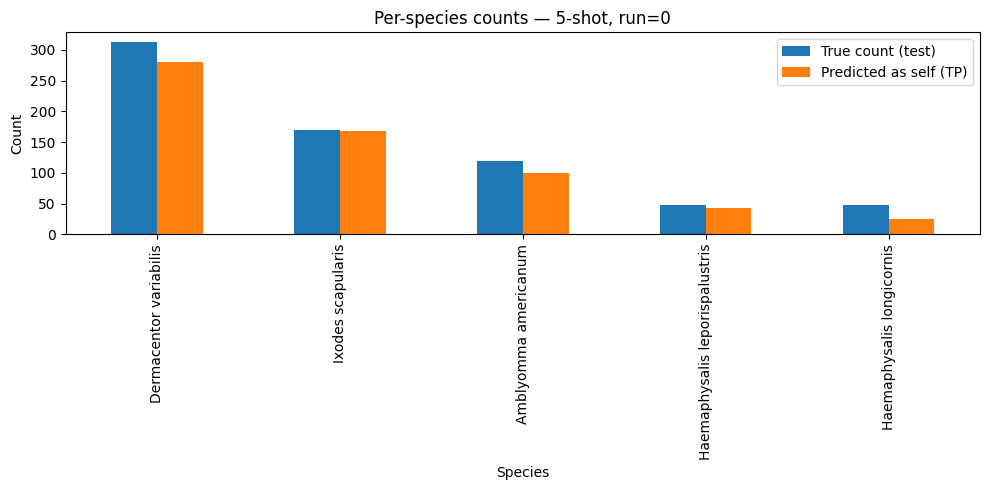


Confusion table (counts) — 5-shot, run=0


pred,Dermacentor variabilis,Ixodes scapularis,Amblyomma americanum,Haemaphysalis leporispalustris,Haemaphysalis longicornis
true,,,,,
Dermacentor variabilis,280,17,7,9,0
Ixodes scapularis,0,168,1,0,0
Amblyomma americanum,1,12,99,6,1
Haemaphysalis leporispalustris,0,0,5,43,0
Haemaphysalis longicornis,0,4,11,7,25


In [8]:
# === Block 5 — Single-run reporting (preview only, no saving yet) ===
# Uses from Block 4: pred_rows, per_class_df, macro_acc, overall_acc, y_true, y_pred
# Globals: CLASS_ORDER, PREVIEW_PLOTS, PLOTS_DIR

import matplotlib.pyplot as plt

# ---- 1) Collect run metadata ----
df_run = pd.DataFrame(pred_rows)
shots  = int(df_run["shots"].iloc[0])
run_id_val = int(df_run["run_id"].iloc[0])

# Prefer the recorded seed; if missing, recompute from (shots, run_id) to keep independence invariant.
if "seed" in df_run.columns and not pd.isna(df_run["seed"].iloc[0]):
    seed = int(df_run["seed"].iloc[0])
else:
    seed = seed_for(shots, run_id_val)

# ---- 2) Per-species summary table ----
tmp = pd.DataFrame({"true": y_true, "pred": y_pred})
per_species = (
    tmp.assign(hit=(tmp.true == tmp.pred).astype(int), one=1)
       .groupby("true")
       .agg(n_test=("one","sum"), n_correct=("hit","sum"))
       .assign(accuracy_species=lambda d: d.n_correct / d.n_test)
       .reset_index()
       .rename(columns={"true": "species"})
)
per_species["shots"] = shots
per_species["seed"]  = seed

with pd.option_context('display.float_format', '{:.3f}'.format):
    print(f"\nRun {run_id_val} (seed={seed}) — Shots {shots} "
          f"| Overall: {overall_acc:.3f} | Macro: {macro_acc:.3f}")
    display(per_species.sort_values("accuracy_species", ascending=False))

# ---- 3) Preview: This is a demo run. Full sweep happens in Block 6 ----
print(f"\n[INFO] This is a single demo run. Use Block 6 to run the full Monte Carlo sweep.")
print(f"[INFO] Results will be saved to: {PREDICTIONS_CSV}")

# ---- 4) Optional quick diagnostic plot for this run ----
if PREVIEW_PLOTS:
    # two-bar per-species: True count vs correctly predicted
    plot_df = (
        per_species.set_index("species")[["n_test","n_correct"]]
                   .reindex(CLASS_ORDER, fill_value=0) if 'CLASS_ORDER' in globals() and CLASS_ORDER is not None
                   else per_species.set_index("species")[["n_test","n_correct"]]
    )
    ax = plot_df.plot(kind="bar", figsize=(10,5), color=["#1f77b4", "#ff7f0e"])
    ax.set_title(f"Per-species counts — {shots}-shot, run={run_id_val}")
    ax.set_xlabel("Species"); ax.set_ylabel("Count")
    ax.legend(["True count (test)", "Predicted as self (TP)"])
    plt.tight_layout()
    plt.show()

    # optional plain confusion table for inspection (numbers only)
    conf_tbl = (
        pd.crosstab(pd.Series(y_true, name="true", dtype=object),
                    pd.Series(y_pred, name="pred", dtype=object))
    )
    if 'CLASS_ORDER' in globals() and CLASS_ORDER is not None:
        conf_tbl = conf_tbl.reindex(index=CLASS_ORDER, columns=CLASS_ORDER, fill_value=0)
    else:
        conf_tbl = conf_tbl.fillna(0).astype(int)
    print(f"\nConfusion table (counts) — {shots}-shot, run={run_id_val}")
    display(conf_tbl.astype(int))

## Block 6 Monte Carlo, 100 seeds. 

In [9]:
# === Block 6 — Monte Carlo sweep (shots × RUNS), saves to PREDICTIONS_CSV ===
# Assumes Blocks 0–5 are loaded.

from tqdm.auto import tqdm
import traceback

print(f"[INIT] Starting Monte Carlo sweep")
print(f"[INIT] Run ID: {RUN_ID}")
print(f"[INIT] Output: {PREDICTIONS_CSV}")
print(f"[INIT] Shots: {SHOTS} | Runs per shot: {RUNS}")

# Turn off any preview/saving during the sweep
_PREV, _SAVE = globals().get("PREVIEW_PLOTS", False), globals().get("SAVE_PLOTS", False)
PREVIEW_PLOTS, SAVE_PLOTS = False, False

failed_runs = []   # (shots, run_id, error_message)
all_pred_rows = [] # collect all predictions here

# (optional) helper to keep split seeding consistent in one place
def split_for_run(by_species, species_list, k, run_id):
    return split_once(by_species, species_list, k=k, seed=seed_for(k, run_id))

for shots in SHOTS:                             # e.g., [1, 3, 5, 10, 25]
    pbar = tqdm(range(RUNS), desc=f"{shots}-shot runs", leave=True)
    for run_id in pbar:                         # 0..RUNS-1
        try:
            # 1) Split — seed derived from (shots, run_id) for independence
            train_pairs, test_pairs, split_counts, n_test_run = split_for_run(
                by_species, included_species, k=shots, run_id=run_id
            )

            # 2) Train + predict + collect rows
            pred_rows, per_class_df, macro_acc, overall_acc, y_true, y_pred = train_predict_collect(
                by_species, train_pairs, test_pairs,
                shots=shots, run_id=run_id, n_test_run=n_test_run
            )

            # 3) Collect predictions
            all_pred_rows.extend(pred_rows)

            # Update tqdm summary
            pbar.set_postfix(rows=len(pred_rows),
                             macro=f"{macro_acc:.3f}", overall=f"{overall_acc:.3f}")

        except Exception as e:
            failed_runs.append((shots, run_id, str(e)))
            print(f"[ERROR] shots={shots} run_id={run_id} | {e}")
            # traceback.print_exc()  # uncomment for deep debugging

# Restore flags
PREVIEW_PLOTS, SAVE_PLOTS = _PREV, _SAVE

# --- Save all predictions to PREDICTIONS_CSV ---
df_all = pd.DataFrame(all_pred_rows)
df_all["sample_id"] = df_all["sample_id"].astype(str)
df_all.to_csv(PREDICTIONS_CSV, index=False)

# --- Sweep summary + sanity checks ---
print("\n" + "=" * 60)
print("Block 6 sweep complete")
print("=" * 60)
print(f"Run ID: {RUN_ID}")
print(f"Predictions file: {PREDICTIONS_CSV}")
print(f"Total rows written: {len(df_all)}")

if len(failed_runs):
    print(f"\nFailures: {len(failed_runs)}")
    for shots_, run_id_, msg in failed_runs[:10]:
        print(f"  shots={shots_} run_id={run_id_} -> {msg}")
    if len(failed_runs) > 10:
        print("  ... (truncated)")

# Quick duplicate sanity check on keys
n_dupes = df_all.duplicated(subset=["shots", "run_id", "sample_id"]).sum()
print(f"Duplicate rows on (shots, run_id, sample_id): {n_dupes}")

# Summary stats
print(f"\nPredictions breakdown:")
for K in SHOTS:
    count = len(df_all[df_all["shots"] == K])
    print(f"  {K}-shot: {count} rows")

print("=" * 60)


[INIT] Starting Monte Carlo sweep
[INIT] Run ID: 260518_000631_dorsal
[INIT] Output: /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/predictions.csv
[INIT] Shots: [1, 3, 5, 10, 25, 35] | Runs per shot: 100


1-shot runs:   0%|          | 0/100 [00:00<?, ?it/s]

Seed: 10042 | Shots: 1 | Run: 0
Overall accuracy: 0.257
Macro (balanced) accuracy: 0.353


,sample_id,true_label,pred_label,pred_confidence
0,T4780,Amblyomma americanum,Haemaphysalis longicornis,0.202505
1,311-01,Amblyomma americanum,Haemaphysalis longicornis,0.200000
2,428-01,Amblyomma americanum,Haemaphysalis longicornis,0.202141
3,491-01,Amblyomma americanum,Haemaphysalis leporispalustris,0.200000
4,34-01,Amblyomma americanum,Haemaphysalis longicornis,0.205960
5,195-01,Amblyomma americanum,Haemaphysalis longicornis,0.200945
6,ZOE-0013-02,Amblyomma americanum,Haemaphysalis leporispalustris,0.200829
7,61-01,Amblyomma americanum,Amblyomma americanum,0.201108
8,ZOE-0014-14,Amblyomma americanum,Haemaphysalis longicornis,0.200000
9,ZOE-0014-02,Amblyomma americanum,Haemaphysalis leporispalustris,0.200940


Seed: 10043 | Shots: 1 | Run: 1
Overall accuracy: 0.686
Macro (balanced) accuracy: 0.584


...

Seed: 350140 | Shots: 35 | Run: 98
Overall accuracy: 0.910
Macro (balanced) accuracy: 0.937


,sample_id,true_label,pred_label,pred_confidence
0,56-05,Amblyomma americanum,Amblyomma americanum,0.770313
1,276-01,Amblyomma americanum,Amblyomma americanum,0.821274
2,T14619,Amblyomma americanum,Amblyomma americanum,0.762910
3,414-01,Amblyomma americanum,Amblyomma americanum,0.960118
4,T19738,Amblyomma americanum,Amblyomma americanum,0.983782
5,150-01,Amblyomma americanum,Amblyomma americanum,0.986699
6,342-01,Amblyomma americanum,Amblyomma americanum,0.761914
7,61-02,Amblyomma americanum,Amblyomma americanum,0.820453
8,T19740,Amblyomma americanum,Amblyomma americanum,0.888182
9,T14584,Amblyomma americanum,Amblyomma americanum,0.851440


Seed: 350141 | Shots: 35 | Run: 99
Overall accuracy: 0.894
Macro (balanced) accuracy: 0.917


,sample_id,true_label,pred_label,pred_confidence
0,T14740,Amblyomma americanum,Amblyomma americanum,0.583354
1,39-01,Amblyomma americanum,Amblyomma americanum,0.657700
2,37-02,Amblyomma americanum,Amblyomma americanum,0.737260
3,T19740,Amblyomma americanum,Amblyomma americanum,0.751931
4,ZOE-0079-09,Amblyomma americanum,Amblyomma americanum,0.946898
5,T19741,Amblyomma americanum,Amblyomma americanum,0.962956
6,T14622,Amblyomma americanum,Amblyomma americanum,0.893972
7,342-01,Amblyomma americanum,Amblyomma americanum,0.755242
8,191-01,Amblyomma americanum,Amblyomma americanum,0.703761
9,T19743,Amblyomma americanum,Amblyomma americanum,0.963665



Block 6 sweep complete
Run ID: 260518_000631_dorsal
Predictions file: /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/predictions.csv
Total rows written: 393100
Duplicate rows on (shots, run_id, sample_id): 0

Predictions breakdown:
  1-shot: 71600 rows
  3-shot: 70600 rows
  5-shot: 69600 rows
  10-shot: 67100 rows
  25-shot: 59600 rows
  35-shot: 54600 rows


## Block 7 Aggregating Results

In [10]:
# === Block 7 — Aggregate metrics per shot and per species (run-aware, with 95% CIs) ===

# Load this run's predictions
df = pd.read_csv(PREDICTIONS_CSV)
print(f"[LOAD] Loaded {len(df)} rows from {PREDICTIONS_CSV}")

# Ensure types and stable ordering
df["shots"]  = df["shots"].astype(int)
df["run_id"] = df["run_id"].astype(int)
df["correct"] = df["correct"].astype(int)
df = df.sort_values(["shots", "run_id", "sample_id"]).reset_index(drop=True)

# ---- helper: 95% CI via normal approx (works well with >=30 runs); fall back if n<2
import numpy as _np

def mean_std_ci95(x):
    x = _np.asarray(x, dtype=float)
    n = x.size
    mean = float(_np.mean(x)) if n else float("nan")
    std  = float(_np.std(x, ddof=1)) if n > 1 else float("nan")
    sem  = std / _np.sqrt(n) if (n and _np.isfinite(std)) else float("nan")
    ci95 = 1.96 * sem if _np.isfinite(sem) else float("nan")
    return mean, std, n, ci95

# --- 1) Per-run summaries (overall + macro) ---
# overall acc per (shots, run)
run_overall = (
    df.groupby(["shots", "run_id"], as_index=False)["correct"]
      .mean()
      .rename(columns={"correct": "overall_acc"})
)

# per-species acc within a run
per_run_species = (
    df.groupby(["shots", "run_id", "species_true"], as_index=False)["correct"]
      .mean()
      .rename(columns={"correct": "spec_acc"})
)

# macro acc per (shots, run) = mean over species present in that run
run_macro = (
    per_run_species.groupby(["shots", "run_id"], as_index=False)["spec_acc"]
      .mean()
      .rename(columns={"spec_acc": "macro_acc"})
)

agg_runs = (
    run_overall.merge(run_macro, on=["shots", "run_id"])
               .sort_values(["shots", "run_id"])
               .reset_index(drop=True)
)

# Save to analysis directory
agg_runs.to_csv(ANALYSIS_DIR / "aggregated_metrics.csv", index=False)
print(f"[SAVE] aggregated_metrics.csv -> {ANALYSIS_DIR}")

# --- 2) Aggregate per shot (mean ± sd and 95% CIs over runs) ---
shot_rows = []
for K, g in agg_runs.groupby("shots"):
    m_macro, s_macro, n_macro, ci_macro = mean_std_ci95(g["macro_acc"].values)
    m_over , s_over , n_over , ci_over  = mean_std_ci95(g["overall_acc"].values)
    shot_rows.append({
        "shots": K,
        "mean_macro": m_macro, "std_macro": s_macro, "ci95_macro": ci_macro, "n_runs_macro": n_macro,
        "mean_overall": m_over, "std_overall": s_over, "ci95_overall": ci_over, "n_runs_overall": n_over
    })

agg_shots = pd.DataFrame(shot_rows).sort_values("shots")
agg_shots.to_csv(ANALYSIS_DIR / "shot_summary.csv", index=False)
print(f"[SAVE] shot_summary.csv -> {ANALYSIS_DIR}")
display(agg_shots)

# --- 3) Per-species learning curves (mean ± sd and 95% CIs over runs) ---
species_rows = []
for (K, sp), g in per_run_species.groupby(["shots", "species_true"]):
    m, s, n, ci = mean_std_ci95(g["spec_acc"].values)
    species_rows.append({
        "shots": K,
        "species": sp,
        "acc_mean": m,
        "acc_std": s,
        "acc_ci95": ci,
        "n_runs": n,
    })

per_species_summary = (
    pd.DataFrame(species_rows)
      .sort_values(["species", "shots"])
      .reset_index(drop=True)
)

per_species_summary.to_csv(ANALYSIS_DIR / "per_species_accuracy.csv", index=False)
print(f"[SAVE] per_species_accuracy.csv -> {ANALYSIS_DIR}")
display(per_species_summary.head(10))

# Alias for downstream blocks
per_species = per_species_summary.copy()

[LOAD] Loaded 393100 rows from /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/predictions.csv
[SAVE] aggregated_metrics.csv -> /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/analysis
[SAVE] shot_summary.csv -> /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/analysis


,shots,mean_macro,std_macro,ci95_macro,n_runs_macro,mean_overall,std_overall,ci95_overall,n_runs_overall
0,1,0.603207,0.088503,0.017347,100,0.672444,0.136665,0.026786,100
1,3,0.745257,0.047486,0.009307,100,0.792365,0.043744,0.008574,100
2,5,0.798775,0.039104,0.007664,100,0.831336,0.029483,0.005779,100
3,10,0.855940,0.028335,0.005554,100,0.873398,0.017034,0.003339,100
4,25,0.901385,0.017340,0.003399,100,0.901795,0.012312,0.002413,100
5,35,0.912965,0.017254,0.003382,100,0.908846,0.010215,0.002002,100


[SAVE] per_species_accuracy.csv -> /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/analysis


,shots,species,acc_mean,acc_std,acc_ci95,n_runs
0,1,Amblyomma americanum,0.370976,0.181179,0.035511,100
1,3,Amblyomma americanum,0.609587,0.172227,0.033757,100
2,5,Amblyomma americanum,0.701008,0.140616,0.027561,100
3,10,Amblyomma americanum,0.819123,0.077989,0.015286,100
4,25,Amblyomma americanum,0.867475,0.044397,0.008702,100
5,35,Amblyomma americanum,0.877865,0.042573,0.008344,100
6,1,Dermacentor variabilis,0.803407,0.249794,0.048960,100
7,3,Dermacentor variabilis,0.859238,0.059962,0.011752,100
8,5,Dermacentor variabilis,0.865974,0.035967,0.007050,100
9,10,Dermacentor variabilis,0.877468,0.023118,0.004531,100


## block 7b comparison with broken specimen

In [11]:
# # === Block 7B — Comparison sweep: WITH broken specimens ===
# # Loads the full dataset (before broken-specimen removal), excludes only
# # incomplete "Ixodes" genus-only labels, then runs the same Monte Carlo sweep.

# import json
# from collections import defaultdict
# from tqdm import tqdm

# # --- File paths ---
# FULL_DATA        = paths['processed_dir'] / 'final_data.json'
# FULL_CLASS_NAMES = paths['processed_dir'] / 'class_names.json'

# print(f"[PATH] Full dataset:    {FULL_DATA}")
# print(f"[PATH] Full class list: {FULL_CLASS_NAMES}")
# print(f"[PATH] Clean dataset (reference): {DATA}")

# with open(FULL_CLASS_NAMES, "r") as f:
#     full_species_list = set(json.load(f))

# with open(FULL_DATA, "r") as f:
#     full_data = json.load(f)

# # Exclude only "Ixodes" genus-only (incomplete label) — keep broken specimens
# EXCLUDE_LABELS = {"Ixodes"}
# full_species_list = {s for s in full_species_list if s not in EXCLUDE_LABELS}

# # Build specimen index (same logic as Block 1)
# by_species_wb = defaultdict(lambda: defaultdict(dict))
# for r in full_data:
#     sp = r["true_label"]
#     if sp not in full_species_list:
#         continue
#     sid = r["sample_id"]
#     view = str(r["view"]).strip().lower()
#     by_species_wb[sp][sid][view] = r["image_path"]

# # Keep only specimens with BOTH views
# for sp in list(by_species_wb.keys()):
#     for sid in list(by_species_wb[sp].keys()):
#         views = by_species_wb[sp][sid]
#         if not ("dorsal" in views and "ventral" in views):
#             del by_species_wb[sp][sid]
#     if not by_species_wb[sp]:
#         del by_species_wb[sp]

# # Enforce MIN_TOTAL
# for sp in list(by_species_wb.keys()):
#     if len(by_species_wb[sp]) < MIN_TOTAL:
#         del by_species_wb[sp]

# included_species_wb = sorted(by_species_wb.keys())

# n_specimens_wb = sum(len(smap) for smap in by_species_wb.values())
# print(f"\nWith-broken dataset:")
# print(f"  Included species: {len(included_species_wb)}")
# print(f"  Total specimens:  {n_specimens_wb}")
# for sp in included_species_wb:
#     n_clean = len(by_species.get(sp, {}))
#     n_wb = len(by_species_wb[sp])
#     diff = n_wb - n_clean
#     print(f"    {sp}: {n_wb} specimens (clean: {n_clean}, +{diff} broken)")

# # --- Run Monte Carlo sweep (same SHOTS, RUNS, seeds as Block 6) ---
# print(f"\n[SWEEP] Monte Carlo: SHOTS={SHOTS}, RUNS={RUNS}")

# all_pred_rows_wb = []
# failed_runs_wb = []

# for shots_k in SHOTS:
#     pbar = tqdm(range(RUNS), desc=f"{shots_k}-shot (with broken)", leave=True)
#     for run_id in pbar:
#         try:
#             seed = seed_for(shots_k, run_id)
#             train_pairs, test_pairs, _, n_test_run = split_once(
#                 by_species_wb, included_species_wb, k=shots_k, seed=seed
#             )

#             Xtr, ytr, _      = build_xy(by_species_wb, train_pairs)
#             Xte, yte, te_ids = build_xy(by_species_wb, test_pairs)

#             clf = Pipeline([
#                 ("scaler", StandardScaler()),
#                 ("svm", SVC(kernel="rbf", class_weight="balanced",
#                             probability=True, random_state=seed))
#             ])
#             clf.fit(Xtr, ytr)
#             yhat  = clf.predict(Xte)
#             probs = clf.predict_proba(Xte)
#             conf  = probs.max(axis=1)

#             overall_acc = accuracy_score(yte, yhat)
#             tmp = pd.DataFrame({"true": yte, "pred": yhat})
#             macro_acc = float(
#                 tmp.assign(hit=(tmp.true == tmp.pred).astype(int))
#                    .groupby("true")["hit"].mean().mean()
#             )

#             for sid, t, p, c in zip(te_ids, yte, yhat, conf):
#                 all_pred_rows_wb.append({
#                     "shots": int(shots_k), "run_id": int(run_id),
#                     "seed": int(seed), "sample_id": str(sid),
#                     "species_true": str(t), "species_pred": str(p),
#                     "correct": int(t == p), "conf_top1": float(c),
#                     "n_test_run": int(n_test_run)
#                 })

#             pbar.set_postfix(macro=f"{macro_acc:.3f}", overall=f"{overall_acc:.3f}")

#         except Exception as e:
#             failed_runs_wb.append((shots_k, run_id, str(e)))

# df_wb = pd.DataFrame(all_pred_rows_wb)

# # --- Aggregate (same logic as Block 7) ---
# df_wb["shots"]   = df_wb["shots"].astype(int)
# df_wb["run_id"]  = df_wb["run_id"].astype(int)
# df_wb["correct"] = df_wb["correct"].astype(int)

# run_overall_wb = (
#     df_wb.groupby(["shots", "run_id"], as_index=False)["correct"]
#          .mean().rename(columns={"correct": "overall_acc"})
# )
# per_run_species_wb = (
#     df_wb.groupby(["shots", "run_id", "species_true"], as_index=False)["correct"]
#          .mean().rename(columns={"correct": "spec_acc"})
# )
# run_macro_wb = (
#     per_run_species_wb.groupby(["shots", "run_id"], as_index=False)["spec_acc"]
#          .mean().rename(columns={"spec_acc": "macro_acc"})
# )
# agg_runs_wb = (
#     run_overall_wb.merge(run_macro_wb, on=["shots", "run_id"])
#                   .sort_values(["shots", "run_id"]).reset_index(drop=True)
# )

# shot_rows_wb = []
# for K, g in agg_runs_wb.groupby("shots"):
#     m_macro, s_macro, n_macro, ci_macro = mean_std_ci95(g["macro_acc"].values)
#     m_over,  s_over,  n_over,  ci_over  = mean_std_ci95(g["overall_acc"].values)
#     shot_rows_wb.append({
#         "shots": K,
#         "mean_macro": m_macro, "std_macro": s_macro,
#         "ci95_macro": ci_macro, "n_runs_macro": n_macro,
#         "mean_overall": m_over, "std_overall": s_over,
#         "ci95_overall": ci_over, "n_runs_overall": n_over,
#     })

# agg_shots_with_broken = pd.DataFrame(shot_rows_wb).sort_values("shots")

# # Save to analysis dir
# agg_shots_with_broken.to_csv(ANALYSIS_DIR / "shot_summary_with_broken.csv", index=False)
# print(f"\n[SAVE] shot_summary_with_broken.csv -> {ANALYSIS_DIR}")

# print("\n[DONE] With-broken aggregated results:")
# display(agg_shots_with_broken)

# if failed_runs_wb:
#     print(f"\n[WARN] Failed runs: {len(failed_runs_wb)}")
#     for s, r, msg in failed_runs_wb[:5]:
#         print(f"  shots={s} run={r}: {msg}")

## Block 8 - Plots

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/macro_accuracy_curve.png


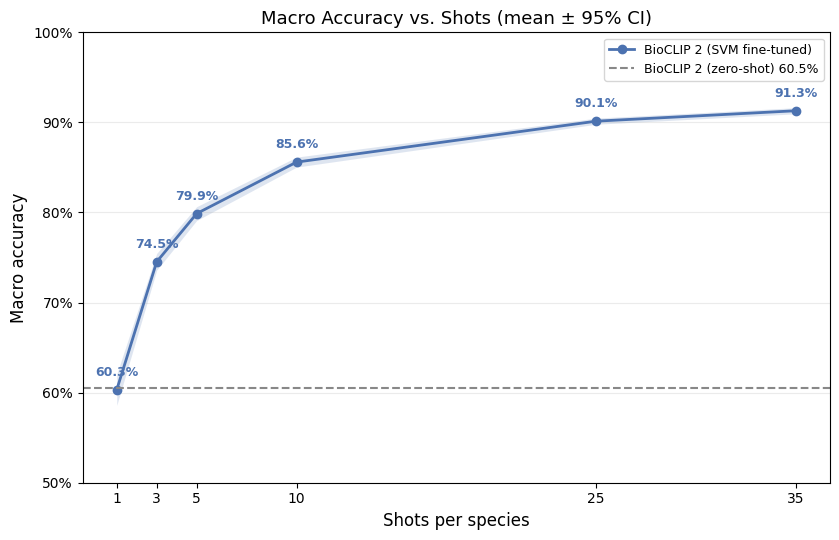

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/species_learning_curves_page01.png


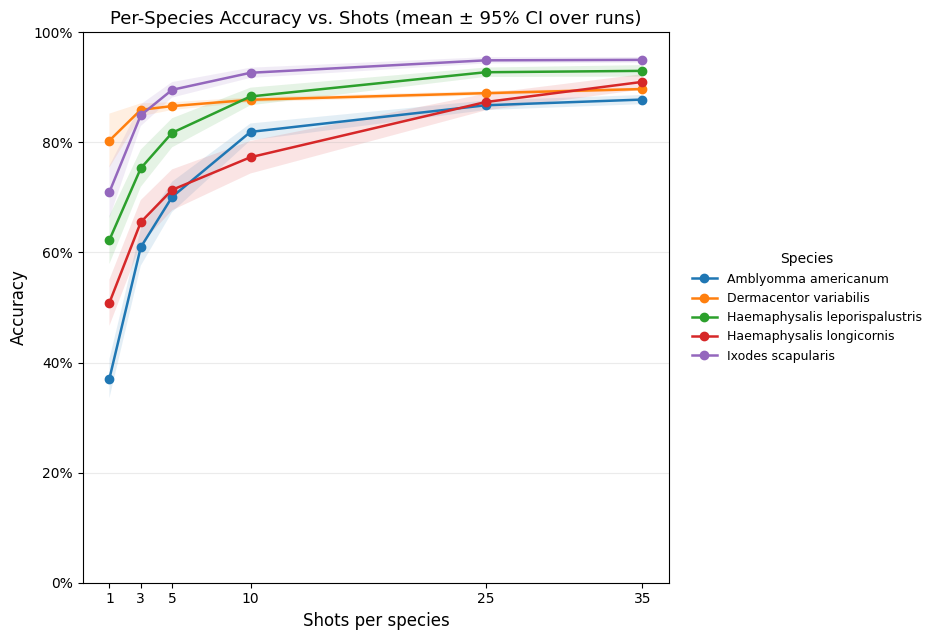

In [12]:

# === Block 8 — Visualization: Macro curve + per-species learning curves ===
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import math
import numpy as np
from pathlib import Path

# ---------- 1) Macro accuracy per shot ----------
fig, ax = plt.subplots(figsize=(8.5, 5.5))

COLOR = "#4C72B0"   # steel blue

x  = agg_shots["shots"].to_numpy()
y  = agg_shots["mean_macro"].to_numpy()
ci = agg_shots["ci95_macro"].to_numpy()

ax.plot(x, y, marker="o", linewidth=2.0, color=COLOR, label="BioCLIP 2 (SVM fine-tuned)")
ax.fill_between(x, y - ci, y + ci, alpha=0.18, color=COLOR, linewidth=0)

for xi, yi in zip(x, y):
    ax.annotate(f"{yi*100:.1f}%", (xi, yi),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, fontweight="semibold", color=COLOR)

# ---- BioCLIP zero-shot baseline ----
bioclip_npz = Path((paths['bioclip_results_dir'] / "latest_run.txt").read_text().strip())
bc = np.load(bioclip_npz, allow_pickle=True)
bioclip_macro = float(bc['macro_acc'][0])

ax.axhline(bioclip_macro, color='#888888', linestyle='--', linewidth=1.5,
           label=f"BioCLIP 2 (zero-shot) {bioclip_macro*100:.1f}%")

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0.5, 1.0)
ax.set_xlabel("Shots per species", fontsize=12)
ax.set_ylabel("Macro accuracy", fontsize=12)
ax.set_title("Macro Accuracy vs. Shots (mean ± 95% CI)", fontsize=13)
ax.set_xticks(x)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(fontsize=9)
plt.tight_layout()

if SAVE_PLOTS:
    out = PLOTS_DIR / "macro_accuracy_curve.png"
    plt.savefig(out, dpi=200)
    print(f"[PLOT] saved {out}")
plt.show()

# ---------- 2) Per-species learning curves (95% CI, sorted, paginated) ----------
K_max = int(np.max(per_species_summary["shots"]))
lastK = (per_species_summary.query("shots == @K_max")
         .sort_values("acc_mean", ascending=False)["species"].tolist())

species_order = lastK
shots_grid = np.sort(per_species_summary["shots"].unique())

SPEC_PER_PAGE = 12
num_pages = math.ceil(len(species_order) / SPEC_PER_PAGE)

for page in range(num_pages):
    start = page * SPEC_PER_PAGE
    end   = start + SPEC_PER_PAGE
    subset = species_order[start:end]
    subdf = per_species_summary[per_species_summary["species"].isin(subset)].copy()

    fig, ax = plt.subplots(figsize=(9.5, 6.5))
    for sp, g in subdf.groupby("species"):
        g = (g.set_index("shots")
               .reindex(shots_grid)
               .reset_index())
        y  = g["acc_mean"].to_numpy()
        ci = g["acc_ci95"].to_numpy()
        ax.plot(shots_grid, y, marker="o", linewidth=1.8, label=sp)
        lo = (y - ci); hi = (y + ci)
        ax.fill_between(shots_grid, lo, hi, alpha=0.12, linewidth=0)

    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xticks(shots_grid)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Shots per species", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ttl = "Per-Species Accuracy vs. Shots (mean ± 95% CI over runs)"
    if num_pages > 1:
        ttl += f"  —  page {page+1}/{num_pages}"
    ax.set_title(ttl, fontsize=13)
    ax.grid(True, axis="y", alpha=0.25)

    leg = ax.legend(title="Species", loc="center left", bbox_to_anchor=(1.02, 0.5),
                    frameon=False, fontsize=9, title_fontsize=10)
    plt.tight_layout()

    if SAVE_PLOTS:
        out = PLOTS_DIR / f"species_learning_curves_page{page+1:02d}.png"
        plt.savefig(out, dpi=200, bbox_inches="tight")
        print(f"[PLOT] saved {out}")
    plt.show()


## # === Block 8B — Combined: Per-species accuracy + macro accuracy overlay ===

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/combined_species_macro_curve.png


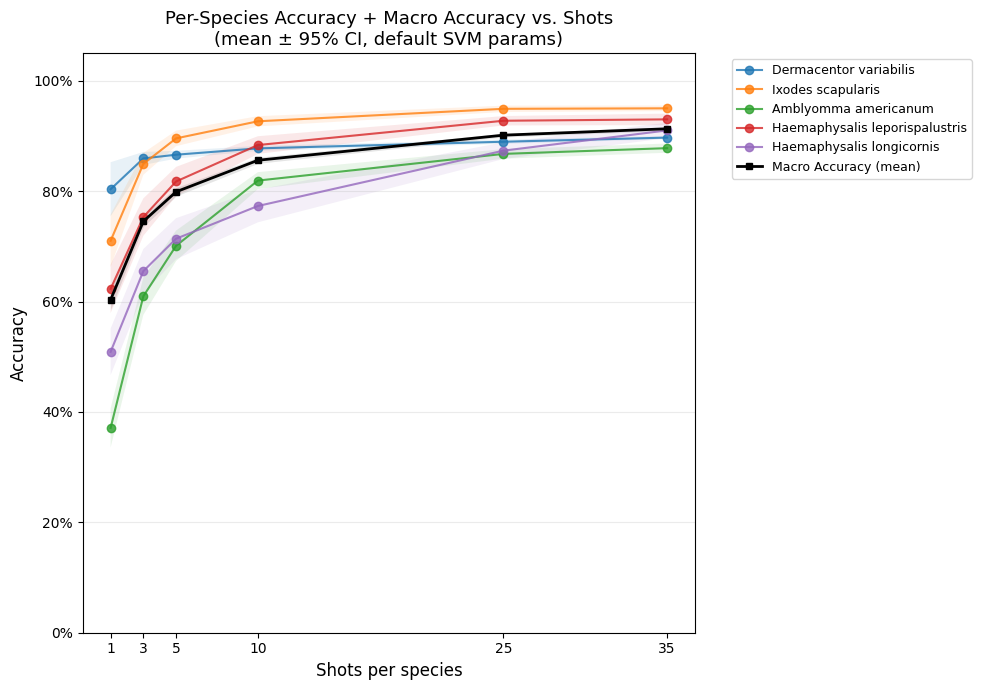

In [13]:
# === Block 8B — Combined: Per-species accuracy + macro accuracy overlay ===

fig, ax = plt.subplots(figsize=(10, 7))

shots_grid = np.sort(per_species_summary["shots"].unique())

# Plot per-species lines
for sp in CLASS_ORDER:
    sp_data = per_species_summary[per_species_summary["species"] == sp].copy()
    sp_data = sp_data.set_index("shots").reindex(shots_grid).reset_index()
    y = sp_data["acc_mean"].to_numpy()
    ci = sp_data["acc_ci95"].to_numpy()
    ax.plot(shots_grid, y, marker="o", linewidth=1.5, label=sp, alpha=0.8)
    ax.fill_between(shots_grid, y - ci, y + ci, alpha=0.1, linewidth=0)

# Overlay macro accuracy as black line (thinner, no annotations)
x_macro = agg_shots["shots"].to_numpy()
y_macro = agg_shots["mean_macro"].to_numpy()
ci_macro = agg_shots["ci95_macro"].to_numpy()
ax.plot(x_macro, y_macro, marker="s", linewidth=2, color="black",
        label="Macro Accuracy (mean)", zorder=10, markersize=5)
ax.fill_between(x_macro, y_macro - ci_macro, y_macro + ci_macro,
                alpha=0.1, color="black", linewidth=0)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xticks(shots_grid)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Shots per species", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Per-Species Accuracy + Macro Accuracy vs. Shots\n(mean ± 95% CI, default SVM params)", fontsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
if SAVE_PLOTS:
    out = PLOTS_DIR / "combined_species_macro_curve.png"
    plt.savefig(out, dpi=200, bbox_inches='tight')
    print(f"[PLOT] saved {out}")
plt.show()

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/confusion_mean_rownorm_K01.png


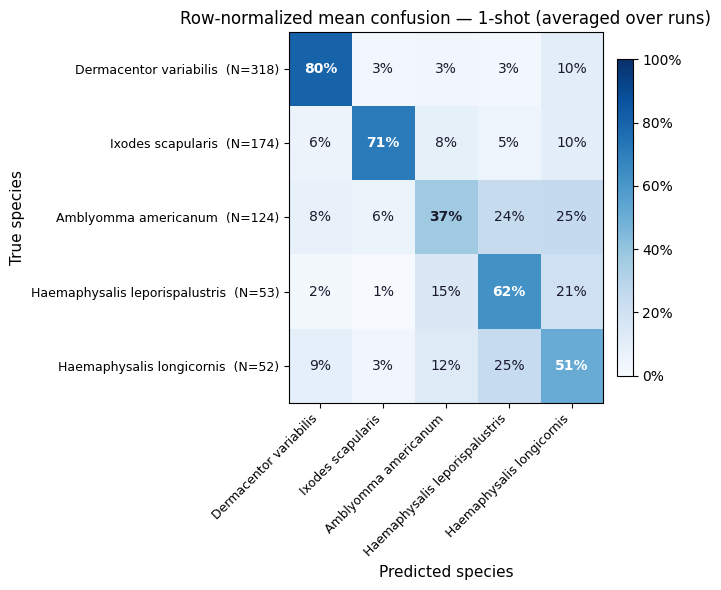

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/confusion_mean_rownorm_K03.png


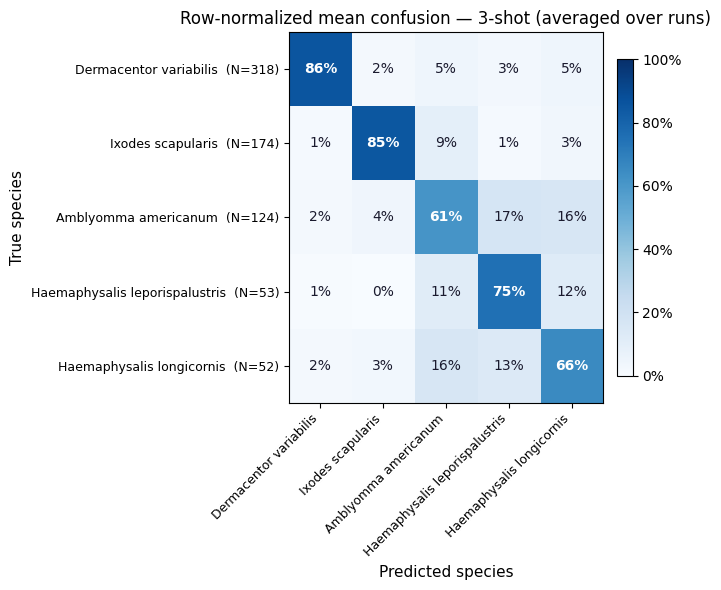

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/confusion_mean_rownorm_K05.png


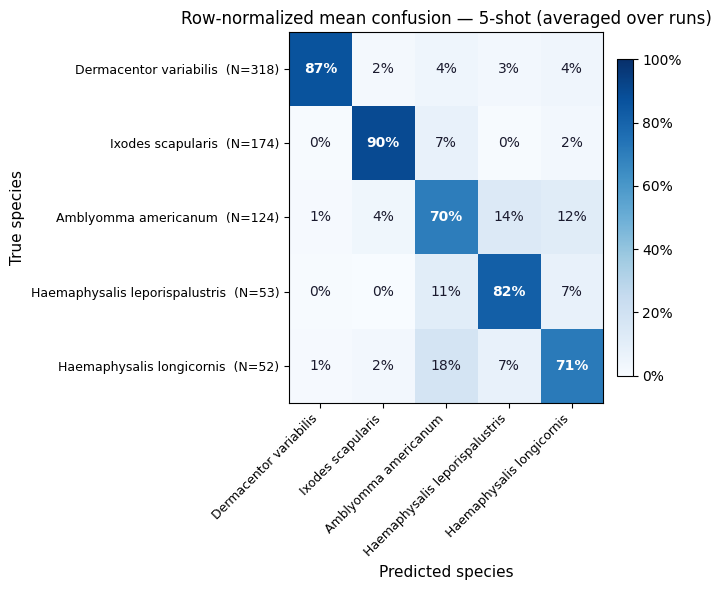

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/confusion_mean_rownorm_K10.png


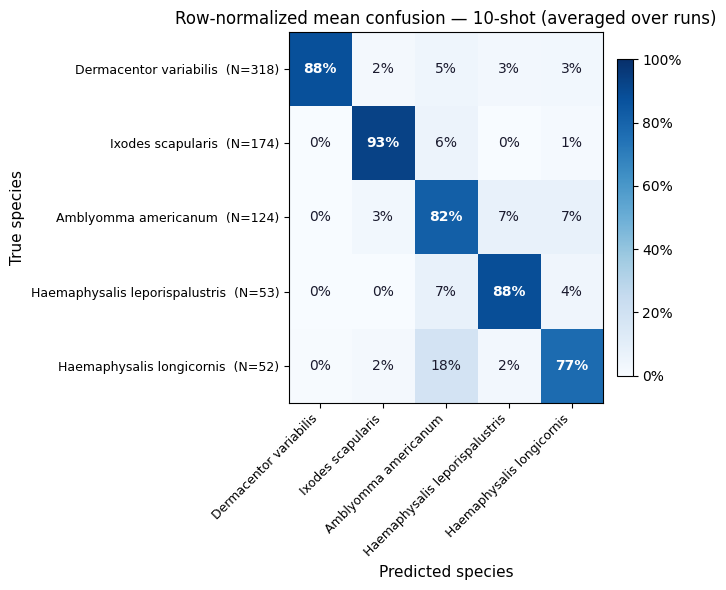

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/confusion_mean_rownorm_K25.png


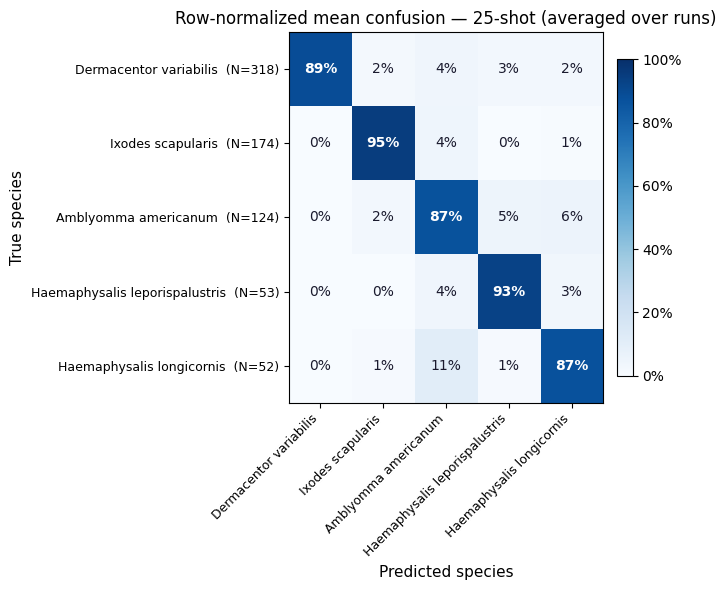

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/confusion_mean_rownorm_K35.png


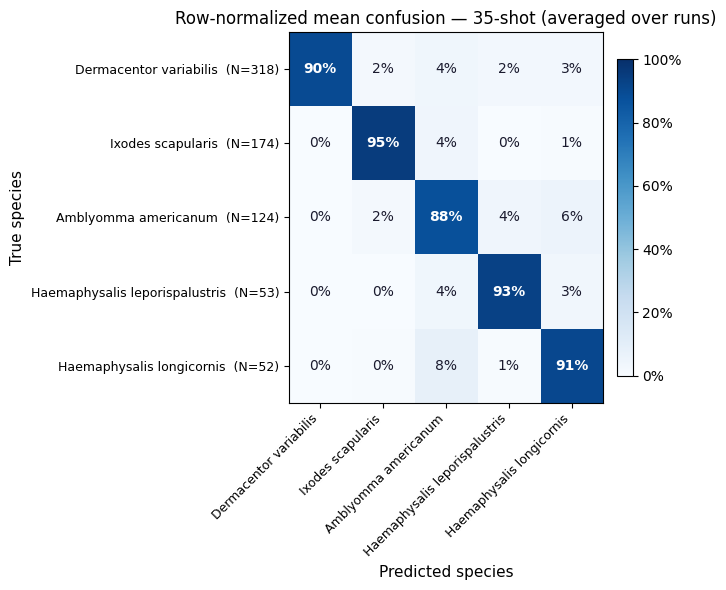

In [14]:
# === Block 9A — Row-normalized mean confusion per K (averaged over runs) ===
# Uses Tableau-style blue gradient for readability
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def mean_rownorm_confusion_for_K(df, K, class_order=None):
    """
    For a given shots K:
      - builds confusion per run (rows=true species)
      - row-normalizes each run's confusion
      - averages row-normalized matrices over runs
    """
    dK = df[df["shots"] == K].copy()
    if class_order is None:
        classes = sorted(pd.unique(dK["species_true"]))
    else:
        classes = [c for c in class_order if c in set(dK["species_true"])]
    n = len(classes)
    if n == 0:
        raise ValueError(f"No classes present at K={K}.")

    mean_conf = np.zeros((n, n), dtype=float)
    row_counts = np.zeros(n, dtype=int)

    for run_id, dKr in dK.groupby("run_id"):
        ct = pd.crosstab(
            pd.Series(dKr["species_true"], name="true"),
            pd.Series(dKr["species_pred"], name="pred")
        )
        ct = ct.reindex(index=classes, columns=classes, fill_value=0)
        m = ct.to_numpy().astype(float)

        row_sums = m.sum(axis=1, keepdims=True)
        nonzero_rows = (row_sums[:, 0] > 0)
        if not np.any(nonzero_rows):
            continue
        m_norm = np.zeros_like(m)
        m_norm[nonzero_rows] = m[nonzero_rows] / row_sums[nonzero_rows]

        mean_conf[nonzero_rows] += m_norm[nonzero_rows]
        row_counts[nonzero_rows] += 1

    for i in range(n):
        if row_counts[i] > 0:
            mean_conf[i] /= row_counts[i]

    return classes, mean_conf, row_counts

def plot_mean_confusion(K, classes, mean_conf, counts_per_row, outpath):
    n = len(classes)
    fig_h = max(6, 0.55 * n)
    fig_w = max(7, 0.7 * n)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(mean_conf, aspect="auto", cmap="Blues", vmin=0, vmax=1)

    y_labels = [f"{cls}  (N={SPECIES_N.get(cls, 0)})" for cls in classes]

    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel("Predicted species", fontsize=11)
    ax.set_ylabel("True species", fontsize=11)
    ax.set_title(f"Row-normalized mean confusion — {K}-shot (averaged over runs)", fontsize=12)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    # Annotate ALL cells with percentages — adaptive text color for readability
    for i in range(n):
        for j in range(n):
            val = mean_conf[i, j]
            text_color = "white" if val > 0.5 else "#1a1a2e"
            fontweight = "bold" if i == j else "normal"
            ax.text(j, i, f"{val*100:.0f}%",
                    ha="center", va="center", fontsize=10,
                    color=text_color, fontweight=fontweight)

    plt.tight_layout()
    
    if SAVE_PLOTS:
        outpath.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(outpath, dpi=200, bbox_inches="tight")
        print(f"[PLOT] saved {outpath}")
    plt.show()

# Generate confusion matrices for all shot levels
for K in SHOTS:
    classes, M, counts = mean_rownorm_confusion_for_K(df, K, class_order=CLASS_ORDER)
    plot_mean_confusion(K, classes, M, counts, PLOTS_DIR / f"confusion_mean_rownorm_K{K:02d}.png")

[PLOT] saved /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/plots/combined_confusion_bioclip_vs_svm35.png


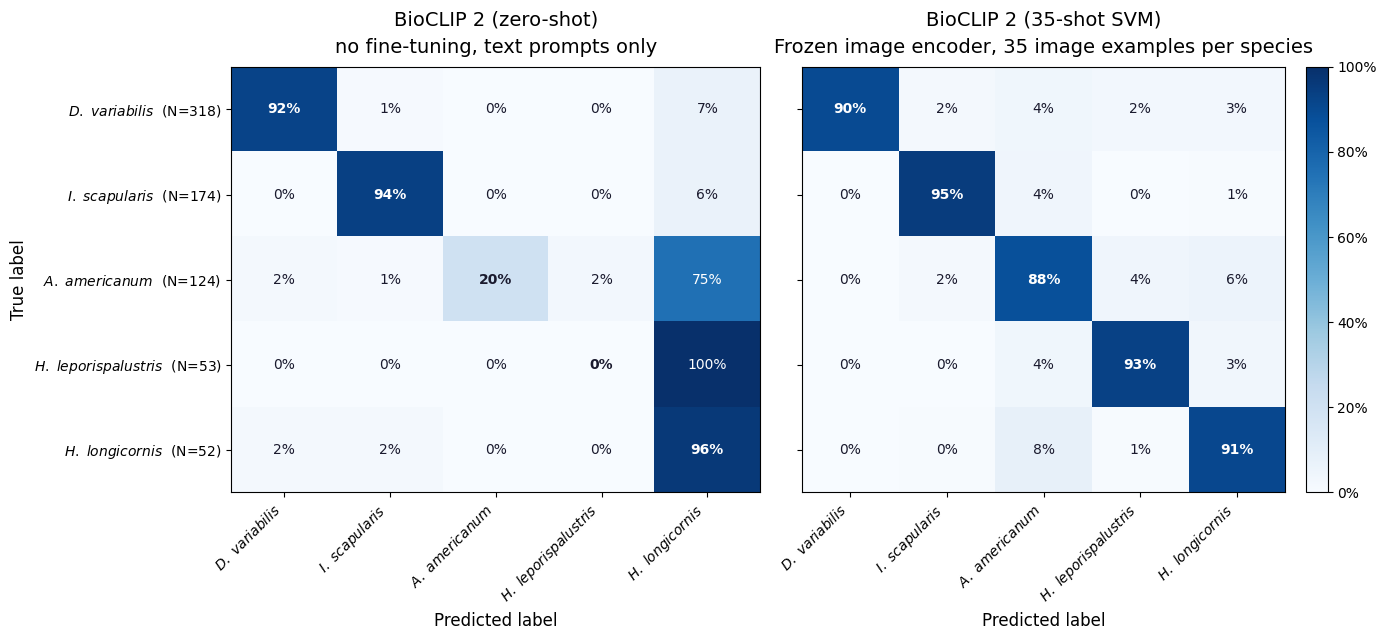

In [15]:

# === Block 9B — Combined figure: BioCLIP zero-shot vs max-shot SVM ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import confusion_matrix
from pathlib import Path

MAX_K = max(SHOTS)  # use highest shot value for comparison

# ---- Load BioCLIP zero-shot results ----
bioclip_npz = Path((paths['bioclip_results_dir'] / "latest_run.txt").read_text().strip())
bc = np.load(bioclip_npz, allow_pickle=True)
bc_ytrue  = list(bc['y_true'])
bc_ypred  = list(bc['y_pred'])
bc_counts = {sp: int(n) for sp, n in zip(bc['large_species'], bc['counts'])}

# ---- SVM max-shot confusion matrix (aligned to CLASS_ORDER) ----
plot_classes, svm_cm, _ = mean_rownorm_confusion_for_K(df, MAX_K, class_order=CLASS_ORDER)
n = len(plot_classes)

# ---- BioCLIP confusion matrix (aligned to same CLASS_ORDER) ----
bc_cm_raw = confusion_matrix(bc_ytrue, bc_ypred, labels=plot_classes)
bc_row_sums = bc_cm_raw.sum(axis=1, keepdims=True)
bc_cm = np.where(bc_row_sums > 0, bc_cm_raw / bc_row_sums, 0)

# ---- Label helper: italic abbreviated genus ----
def abbrev_italic(name):
    parts = name.split()
    return r'$\it{' + parts[0][0] + r'.\ ' + ' '.join(parts[1:]) + r'}$'

x_tick_labels = [abbrev_italic(sp) for sp in plot_classes]
y_tick_labels = [abbrev_italic(sp) + f'  (N={bc_counts.get(sp, 0)})' for sp in plot_classes]

# ---- Figure ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

# --- Left subplot: BioCLIP zero-shot ---
im1 = ax1.imshow(bc_cm, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(n)); ax1.set_yticks(range(n))
ax1.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=10)
ax1.set_yticklabels(y_tick_labels, fontsize=10)
ax1.set_xlabel('Predicted label', fontsize=12)
ax1.set_ylabel('True label', fontsize=12)

# Title + subtitle as a single two-line set_title
ax1.set_title('BioCLIP 2 (zero-shot)\nno fine-tuning, text prompts only',
              fontsize=14, pad=10, linespacing=1.6)
ax1.title.set_fontweight('normal')

for i in range(n):
    for j in range(n):
        val = bc_cm[i, j]
        ax1.text(j, i, f'{val*100:.0f}%', ha='center', va='center',
                 color='white' if val > 0.5 else '#1a1a2e', fontsize=10,
                 fontweight='bold' if i == j else 'normal')

# --- Right subplot: SVM max-shot ---
im2 = ax2.imshow(svm_cm, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax2.set_xticks(range(n)); ax2.set_yticks(range(n))
ax2.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels([])
ax2.set_xlabel('Predicted label', fontsize=12)

ax2.set_title(f'BioCLIP 2 ({MAX_K}-shot SVM)\nFrozen image encoder, {MAX_K} image examples per species',
              fontsize=14, pad=10, linespacing=1.6)
ax2.title.set_fontweight('normal')

for i in range(n):
    for j in range(n):
        val = svm_cm[i, j]
        ax2.text(j, i, f'{val*100:.0f}%', ha='center', va='center',
                 color='white' if val > 0.5 else '#1a1a2e', fontsize=10,
                 fontweight='bold' if i == j else 'normal')

# Colorbar on right subplot only
cbar = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()

if SAVE_PLOTS:
    out = PLOTS_DIR / f'combined_confusion_bioclip_vs_svm{MAX_K}.png'
    plt.savefig(out, dpi=200, bbox_inches='tight')
    print(f'[PLOT] saved {out}')
plt.show()

## Block 10: error analysis

In [16]:
# === Block 10 — Error analysis: CSVs for ALL samples with full stats + image paths ===

from pathlib import Path
import pandas as pd
import numpy as np

# Path to your JSON metadata file
META_JSON = paths['processed_dir'] / 'final_data_cleaned.json'

# Helper functions 
def choose_most_dominant_value(series: pd.Series):
    """Return the most dominant (most frequent) non-null value in a Series."""
    s = series.dropna()
    if s.empty:
        return np.nan
    mode_values = s.mode()
    if len(mode_values) > 0:
        return mode_values.iloc[0]
    return s.iloc[0]

def count_incorrect(series: pd.Series) -> int:
    """Count how many entries are incorrect (assumes 0 = incorrect, 1 = correct)."""
    return int((series == 0).sum())

def count_correct(series: pd.Series) -> int:
    """Count how many entries are correct (assumes 0 = incorrect, 1 = correct)."""
    return int((series == 1).sum())

# ---------------------------------------------------------------------
# 1) Load predictions from this run
# ---------------------------------------------------------------------
df_pred = pd.read_csv(PREDICTIONS_CSV)
print(f"[LOAD] Predictions: {PREDICTIONS_CSV.name}, rows = {len(df_pred)}")

# Ensure types are consistent
df_pred["shots"] = df_pred["shots"].astype(int)
df_pred["run_id"] = df_pred["run_id"].astype(int)
df_pred["correct"] = df_pred["correct"].astype(int)
df_pred["sample_id"] = df_pred["sample_id"].astype(str)

# ---------------------------------------------------------------------
# 2) Load metadata from JSON
# ---------------------------------------------------------------------
if not META_JSON.exists():
    raise FileNotFoundError(f"Metadata JSON not found at {META_JSON}.")

meta_df = pd.read_json(META_JSON)
meta_df["sample_id"] = meta_df["sample_id"].astype(str)

print(f"[LOAD] Metadata JSON: {META_JSON.name}, rows = {len(meta_df)}")

# ---------------------------------------------------------------------
# 3) Collapse metadata to one row per sample_id (with image paths)
# ---------------------------------------------------------------------
# Dominant scalar fields per sample
meta_sample = (
    meta_df
    .groupby("sample_id", as_index=False)
    .agg(
        species_true=("true_label", choose_most_dominant_value),
        sex=("sex", choose_most_dominant_value),
        life_stage=("life_stage", choose_most_dominant_value),
        attached=("attached", choose_most_dominant_value),
    )
)

# Representative dorsal/ventral image paths
dorsal_paths = (
    meta_df[meta_df["view"] == "dorsal"]
    .groupby("sample_id")["image_path"]
    .first()
    .rename("dorsal_image_path")
)
ventral_paths = (
    meta_df[meta_df["view"] == "ventral"]
    .groupby("sample_id")["image_path"]
    .first()
    .rename("ventral_image_path")
)

meta_sample = (
    meta_sample
    .merge(dorsal_paths, on="sample_id", how="left")
    .merge(ventral_paths, on="sample_id", how="left")
)

print(f"[META] Collapsed to {len(meta_sample)} unique sample_ids")

# ---------------------------------------------------------------------
# 4) Build per-sample prediction summary (ALL samples)
# ---------------------------------------------------------------------
# Basic stats per sample_id
sample_stats = (
    df_pred
    .groupby("sample_id", as_index=False)
    .agg(
        n_rows=("correct", "size"),
        n_incorrect=("correct", count_incorrect),
        n_correct=("correct", count_correct),
        mean_conf_overall=("conf_top1", "mean"),
    )
)

sample_stats["incorrect_rate"] = sample_stats["n_incorrect"] / sample_stats["n_rows"]

# Most common wrong label per sample (if any)
wrong_rows = df_pred[df_pred["correct"] == 0].copy()

if len(wrong_rows) > 0:
    wrong_summary = (
        wrong_rows
        .groupby(["sample_id", "species_pred"], as_index=False)
        .agg(
            n_incorrect_pred=("species_pred", "size"),
            mean_conf_when_wrong=("conf_top1", "mean"),
        )
        .sort_values(
            ["sample_id", "n_incorrect_pred", "mean_conf_when_wrong"],
            ascending=[True, False, False],
        )
    )

    top_wrong_per_sample = (
        wrong_summary
        .groupby("sample_id", as_index=False)
        .head(1)
        .rename(
            columns={
                "species_pred": "most_common_wrong_pred",
                "n_incorrect_pred": "n_incorrect_to_most_common",
                "mean_conf_when_wrong": "mean_conf_to_most_common",
            }
        )
        [["sample_id", "most_common_wrong_pred", "n_incorrect_to_most_common", "mean_conf_to_most_common"]]
    )
else:
    top_wrong_per_sample = pd.DataFrame(
        columns=["sample_id", "most_common_wrong_pred", "n_incorrect_to_most_common", "mean_conf_to_most_common"]
    )

sample_stats = sample_stats.merge(top_wrong_per_sample, on="sample_id", how="left")

# Error rate by shot level per sample (err_by_shot_K)
shot_stats = (
    df_pred
    .groupby(["sample_id", "shots"], as_index=False)
    .agg(
        n_rows_shot=("correct", "size"),
        n_incorrect_shot=("correct", count_incorrect),
    )
)

# Pivot shot-level error rates into columns
pivot_nrows = shot_stats.pivot(index="sample_id", columns="shots", values="n_rows_shot")
pivot_ninc = shot_stats.pivot(index="sample_id", columns="shots", values="n_incorrect_shot")
err_by_shot = pivot_ninc / pivot_nrows

# Rename columns like err_by_shot_1, err_by_shot_3, ...
err_by_shot.columns = [f"err_by_shot_{int(k)}" for k in err_by_shot.columns]
err_by_shot = err_by_shot.reset_index()

sample_stats = sample_stats.merge(err_by_shot, on="sample_id", how="left")

# Attach metadata to the sample stats (ALL samples, including image paths)
sample_summary = sample_stats.merge(meta_sample, on="sample_id", how="left")

# Reorder columns for clarity
col_order = [
    "sample_id", "species_true",
    "n_rows", "n_correct", "n_incorrect", "incorrect_rate",
    "most_common_wrong_pred", "n_incorrect_to_most_common", "mean_conf_to_most_common",
    "mean_conf_overall"
]
# Add err_by_shot columns
err_cols = [c for c in sample_summary.columns if c.startswith("err_by_shot_")]
col_order.extend(sorted(err_cols, key=lambda x: int(x.split("_")[-1])))
# Add metadata columns
col_order.extend(["sex", "life_stage", "attached", "dorsal_image_path", "ventral_image_path"])
# Keep only columns that exist
col_order = [c for c in col_order if c in sample_summary.columns]
sample_summary = sample_summary[col_order]

# Sort by incorrect_rate descending (hardest samples first)
sample_summary = sample_summary.sort_values(
    ["incorrect_rate", "n_incorrect"],
    ascending=[False, False]
).reset_index(drop=True)

print(f"[SAMPLE] sample_summary: {len(sample_summary)} samples (ALL samples included)")

# ---------------------------------------------------------------------
# 5) Species-level summary
# ---------------------------------------------------------------------
species_summary = (
    df_pred
    .groupby("species_true", as_index=False)
    .agg(
        n_total_rows=("correct", "size"),
        n_total_incorrect=("correct", count_incorrect),
        n_total_correct=("correct", count_correct),
    )
)
species_summary["error_rate"] = species_summary["n_total_incorrect"] / species_summary["n_total_rows"]

# Most confused-with per species
confusion_summary = (
    df_pred
    .groupby(["species_true", "species_pred"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

true_totals = (
    confusion_summary
    .groupby("species_true", as_index=False)["count"]
    .sum()
    .rename(columns={"count": "true_total"})
)

confusion_summary = confusion_summary.merge(true_totals, on="species_true", how="left")
confusion_summary["rate_within_true"] = confusion_summary["count"] / confusion_summary["true_total"]

# Most confused-with per species (ignore diagonal)
wrong_confusion = confusion_summary[confusion_summary["species_true"] != confusion_summary["species_pred"]].copy()

if len(wrong_confusion) > 0:
    most_confused_with = (
        wrong_confusion
        .sort_values(["species_true", "count"], ascending=[True, False])
        .groupby("species_true", as_index=False)
        .head(1)
        .rename(
            columns={
                "species_pred": "most_confused_with",
                "count": "misclass_count",
                "rate_within_true": "misclass_rate_within_true",
            }
        )
        [["species_true", "most_confused_with", "misclass_count", "misclass_rate_within_true"]]
    )
else:
    most_confused_with = pd.DataFrame(
        columns=["species_true", "most_confused_with", "misclass_count", "misclass_rate_within_true"]
    )

species_summary = species_summary.merge(most_confused_with, on="species_true", how="left")

print(f"[SPECIES] species_summary: {len(species_summary)} species")
print(f"[CONFUSION] confusion_summary: {len(confusion_summary)} pairs")

# ---------------------------------------------------------------------
# 6) Save CSVs to ANALYSIS_DIR
# ---------------------------------------------------------------------

# sample_summary.csv - ALL samples with full stats + image paths (sorted by incorrect_rate)
sample_summary.to_csv(ANALYSIS_DIR / "sample_summary.csv", index=False)
print(f"[SAVE] sample_summary.csv -> {ANALYSIS_DIR} ({len(sample_summary)} rows, sorted by incorrect_rate)")

# species_summary.csv
species_summary.to_csv(ANALYSIS_DIR / "species_summary.csv", index=False)
print(f"[SAVE] species_summary.csv -> {ANALYSIS_DIR} ({len(species_summary)} rows)")

# confusion_summary.csv
confusion_summary.to_csv(ANALYSIS_DIR / "confusion_summary.csv", index=False)
print(f"[SAVE] confusion_summary.csv -> {ANALYSIS_DIR} ({len(confusion_summary)} rows)")

# ---------------------------------------------------------------------
# 7) Preview in notebook
# ---------------------------------------------------------------------
from IPython.display import display

print("\n" + "=" * 60)
print("Block 10 Error Analysis Complete")
print("=" * 60)

print("\n[SAMPLE SUMMARY PREVIEW] (first 5 rows, sorted by incorrect_rate)")
display(sample_summary.head())

print("\n[SPECIES SUMMARY]")
display(species_summary)

print("\n[CONFUSION SUMMARY] (top 10 by count)")
display(confusion_summary.sort_values("count", ascending=False).head(10))

print(f"\n[INFO] All {len(sample_summary)} samples saved to sample_summary.csv")
print(f"[INFO] Sorted by incorrect_rate descending (hardest samples first)")
print("=" * 60)

[LOAD] Predictions: predictions.csv, rows = 393100
[LOAD] Metadata JSON: final_data_cleaned.json, rows = 1442


[META] Collapsed to 721 unique sample_ids


[SAMPLE] sample_summary: 721 samples (ALL samples included)
[SPECIES] species_summary: 5 species
[CONFUSION] confusion_summary: 25 pairs
[SAVE] sample_summary.csv -> /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/analysis (721 rows, sorted by incorrect_rate)
[SAVE] species_summary.csv -> /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/analysis (5 rows)
[SAVE] confusion_summary.csv -> /fs/ess/PAS2136/jjivandas/projects/tick_classification_project/results/svm/runs/260518_000631_dorsal/analysis (25 rows)

Block 10 Error Analysis Complete

[SAMPLE SUMMARY PREVIEW] (first 5 rows, sorted by incorrect_rate)


,sample_id,species_true,n_rows,n_correct,n_incorrect,incorrect_rate,most_common_wrong_pred,n_incorrect_to_most_common,mean_conf_to_most_common,mean_conf_overall,...,err_by_shot_3,err_by_shot_5,err_by_shot_10,err_by_shot_25,err_by_shot_35,sex,life_stage,attached,dorsal_image_path,ventral_image_path
0,T7845,Dermacentor variabilis,578,1,577,0.998270,Haemaphysalis longicornis,343,0.420559,0.379823,...,1.000000,1.000000,1.000000,1.0,1.0,NaN,Nymph,"Yes, unknown length of time",/fs/ess/PAS2136/jjivandas/projects/tick_classi...,/fs/ess/PAS2136/jjivandas/projects/tick_classi...
1,T7844,Dermacentor variabilis,575,1,574,0.998261,Haemaphysalis longicornis,339,0.472883,0.426006,...,1.000000,1.000000,1.000000,1.0,1.0,NaN,Nymph,"Yes, unknown length of time",/fs/ess/PAS2136/jjivandas/projects/tick_classi...,/fs/ess/PAS2136/jjivandas/projects/tick_classi...
2,T19730,Dermacentor variabilis,581,3,578,0.994836,Haemaphysalis longicornis,390,0.482508,0.424459,...,1.000000,0.990000,0.989691,1.0,1.0,NaN,Nymph,No,/fs/ess/PAS2136/jjivandas/projects/tick_classi...,/fs/ess/PAS2136/jjivandas/projects/tick_classi...
3,T14551,Dermacentor variabilis,577,4,573,0.993068,Haemaphysalis leporispalustris,532,0.565544,0.541534,...,0.989899,1.000000,1.000000,1.0,1.0,NaN,Larva,No,/fs/ess/PAS2136/jjivandas/projects/tick_classi...,/fs/ess/PAS2136/jjivandas/projects/tick_classi...
4,T19731,Dermacentor variabilis,575,4,571,0.993043,Haemaphysalis longicornis,445,0.561210,0.497592,...,1.000000,0.989796,1.000000,1.0,1.0,NaN,Nymph,No,/fs/ess/PAS2136/jjivandas/projects/tick_classi...,/fs/ess/PAS2136/jjivandas/projects/tick_classi...



[SPECIES SUMMARY]


,species_true,n_total_rows,n_total_incorrect,n_total_correct,error_rate,most_confused_with,misclass_count,misclass_rate_within_true
0,Amblyomma americanum,66500,20480,46020,0.307970,Haemaphysalis leporispalustris,8396,0.126256
1,Dermacentor variabilis,182900,24789,158111,0.135533,Haemaphysalis longicornis,8396,0.045905
2,Haemaphysalis leporispalustris,23900,4902,18998,0.205105,Haemaphysalis longicornis,2365,0.098954
3,Haemaphysalis longicornis,23300,6988,16312,0.299914,Amblyomma americanum,3431,0.147253
4,Ixodes scapularis,96500,12017,84483,0.124528,Amblyomma americanum,6391,0.066228



[CONFUSION SUMMARY] (top 10 by count)


,species_true,species_pred,count,true_total,rate_within_true
6,Dermacentor variabilis,Dermacentor variabilis,158111,182900,0.864467
24,Ixodes scapularis,Ixodes scapularis,84483,96500,0.875472
0,Amblyomma americanum,Amblyomma americanum,46020,66500,0.692030
12,Haemaphysalis leporispalustris,Haemaphysalis leporispalustris,18998,23900,0.794895
18,Haemaphysalis longicornis,Haemaphysalis longicornis,16312,23300,0.700086
8,Dermacentor variabilis,Haemaphysalis longicornis,8396,182900,0.045905
2,Amblyomma americanum,Haemaphysalis leporispalustris,8396,66500,0.126256
3,Amblyomma americanum,Haemaphysalis longicornis,8297,66500,0.124767
5,Dermacentor variabilis,Amblyomma americanum,7598,182900,0.041542
20,Ixodes scapularis,Amblyomma americanum,6391,96500,0.066228



[INFO] All 721 samples saved to sample_summary.csv
[INFO] Sorted by incorrect_rate descending (hardest samples first)


In [17]:
# # === Block 11 — HTML Sample Gallery with Fed/Unfed Annotations ===
# # Images embedded as base64 data URIs
# # Fed/Unfed annotations persist in browser localStorage across sessions

# from pathlib import Path
# import pandas as pd
# import html
# import base64
# from PIL import Image
# import io

# gallery_path = ANALYSIS_DIR / "sample_gallery.html"

# # ---------------------------------------------------------------------
# # 1) Load the sample summary we created in Block 10
# # ---------------------------------------------------------------------
# sample_summary_path = ANALYSIS_DIR / "sample_summary.csv"

# if not sample_summary_path.exists():
#     raise FileNotFoundError("sample_summary.csv not found. Run Block 10 first.")

# sample_df = pd.read_csv(sample_summary_path)
# print(f"[LOAD] Sample summary: {len(sample_df)} samples")

# # ---------------------------------------------------------------------
# # 2) Helpers
# # ---------------------------------------------------------------------
# _img_cache = {}

# def image_to_base64(path, max_size=400):
#     if path in _img_cache:
#         return _img_cache[path]
#     try:
#         img = Image.open(path).convert("RGB")
#         img.thumbnail((max_size, max_size), Image.LANCZOS)
#         buffer = io.BytesIO()
#         img.save(buffer, format="JPEG", quality=85)
#         b64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
#         data_uri = f"data:image/jpeg;base64,{b64}"
#         _img_cache[path] = data_uri
#         return data_uri
#     except Exception as e:
#         print(f"[WARN] Could not encode image {path}: {e}")
#         return None

# def make_image_tag(path, label):
#     if pd.isna(path) or not Path(str(path)).exists():
#         return f'<div class="img-missing">No {html.escape(label)} image</div>'
#     data_uri = image_to_base64(str(path))
#     if data_uri is None:
#         return f'<div class="img-missing">Could not load {html.escape(label)} image</div>'
#     return f'<img src="{data_uri}" alt="{html.escape(label)}" class="tick-image">'

# def sample_card(row):
#     sample_id = str(row.get("sample_id", ""))
#     true_species = row.get("species_true", "")
#     most_common_pred = row.get("most_common_wrong_pred", "")
#     incorrect_rate = row.get("incorrect_rate", "")
#     n_incorrect = row.get("n_incorrect", "")
#     n_rows = row.get("n_rows", "")
#     sex = row.get("sex", "")
#     life_stage = row.get("life_stage", "")
#     attached = row.get("attached", "")
#     dorsal_path = row.get("dorsal_image_path", "")
#     ventral_path = row.get("ventral_image_path", "")

#     dorsal_img = make_image_tag(dorsal_path, "dorsal")
#     ventral_img = make_image_tag(ventral_path, "ventral")

#     def fmt(x):
#         if isinstance(x, float):
#             if pd.isna(x):
#                 return ""
#             return f"{x:.3f}"
#         return "" if pd.isna(x) else str(x)

#     if n_incorrect == 0:
#         status_badge = '<span class="badge correct">All Correct</span>'
#     elif incorrect_rate > 0.5:
#         status_badge = '<span class="badge hard">Hard Sample</span>'
#     else:
#         status_badge = '<span class="badge some-errors">Some Errors</span>'

#     esc_sid = html.escape(fmt(sample_id))

#     html_block = f"""
#     <div class="sample-card" data-species="{html.escape(fmt(true_species))}" data-incorrect="{fmt(n_incorrect)}" data-rate="{fmt(incorrect_rate)}" data-fed="false">
#       <div class="meta">
#         <div><strong>Sample ID:</strong> {esc_sid} {status_badge}</div>
#         <div><strong>True species:</strong> {html.escape(fmt(true_species))}</div>
#         <div><strong>Most common wrong prediction:</strong> {html.escape(fmt(most_common_pred)) if fmt(most_common_pred) else 'N/A'}</div>
#         <div><strong>Incorrect:</strong> {html.escape(fmt(n_incorrect))} / {html.escape(fmt(n_rows))}
#              (rate = {html.escape(fmt(incorrect_rate))})</div>
#         <div><strong>Sex:</strong> {html.escape(fmt(sex))}</div>
#         <div><strong>Life stage:</strong> {html.escape(fmt(life_stage))}</div>
#         <div><strong>Attached:</strong> {html.escape(fmt(attached))}</div>
#         <div class="fed-status">
#           <label class="fed-label">
#             <input type="checkbox" class="fed-check" data-sample="{esc_sid}" onchange="saveFedStatus(this)">
#             <span class="fed-text">Fed</span>
#           </label>
#         </div>
#       </div>
#       <div class="images">
#         <div class="image-column">
#           <div class="image-label">Dorsal</div>
#           {dorsal_img}
#         </div>
#         <div class="image-column">
#           <div class="image-label">Ventral</div>
#           {ventral_img}
#         </div>
#       </div>
#     </div>
#     """
#     return html_block

# # ---------------------------------------------------------------------
# # 3) Build the HTML document
# # ---------------------------------------------------------------------
# print("[INFO] Encoding images as base64 (this may take a moment)...")

# sample_df_sorted = sample_df.sort_values(
#     ["incorrect_rate", "n_incorrect"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# all_cards = "\n".join(sample_card(row) for _, row in sample_df_sorted.iterrows())

# print(f"[INFO] Encoded {len(_img_cache)} unique images")

# species_list = sorted(sample_df["species_true"].dropna().unique())
# species_options = "\n".join(f'<option value="{html.escape(s)}">{html.escape(s)}</option>' for s in species_list)
# n_samples = len(sample_df)

# full_html = f"""
# <!DOCTYPE html>
# <html>
# <head>
#   <meta charset="utf-8">
#   <title>Tick Sample Gallery - Run {RUN_ID}</title>
#   <style>
#     body {{
#       font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;
#       margin: 20px;
#       background-color: #111;
#       color: #eee;
#     }}
#     h1, h2, h3 {{
#       color: #ffcc66;
#     }}
#     .filters {{
#       background: #222;
#       padding: 15px;
#       border-radius: 8px;
#       margin-bottom: 12px;
#       display: flex;
#       gap: 20px;
#       flex-wrap: wrap;
#       align-items: center;
#     }}
#     .filters label {{
#       font-weight: bold;
#     }}
#     .filters select, .filters input {{
#       padding: 8px;
#       border-radius: 4px;
#       border: 1px solid #444;
#       background: #333;
#       color: #eee;
#     }}
#     .annotation-bar {{
#       background: #1a2a1a;
#       padding: 12px 15px;
#       border-radius: 8px;
#       margin-bottom: 12px;
#       display: flex;
#       gap: 15px;
#       align-items: center;
#       flex-wrap: wrap;
#     }}
#     .export-btn {{
#       padding: 8px 16px;
#       border-radius: 6px;
#       border: 1px solid #4CAF50;
#       background: #2d5a27;
#       color: #90EE90;
#       cursor: pointer;
#       font-weight: bold;
#       font-size: 0.9rem;
#     }}
#     .export-btn:hover {{
#       background: #3d7a37;
#     }}
#     .stats {{
#       background: #1a1a2e;
#       padding: 10px 15px;
#       border-radius: 8px;
#       margin-bottom: 20px;
#     }}
#     .sample-card {{
#       border: 1px solid #444;
#       border-radius: 10px;
#       padding: 12px;
#       margin: 12px 0;
#       background-color: #1b1b1b;
#       display: flex;
#       flex-direction: column;
#       gap: 8px;
#       transition: border-color 0.15s;
#     }}
#     .sample-card.hidden {{
#       display: none;
#     }}
#     .sample-card.marked-fed {{
#       border-color: #e74c3c;
#       border-width: 2px;
#     }}
#     .badge {{
#       padding: 2px 8px;
#       border-radius: 4px;
#       font-size: 0.8rem;
#       margin-left: 10px;
#     }}
#     .badge.correct {{
#       background: #2d5a27;
#       color: #90EE90;
#     }}
#     .badge.hard {{
#       background: #5a2727;
#       color: #FF6B6B;
#     }}
#     .badge.some-errors {{
#       background: #5a4a27;
#       color: #FFD93D;
#     }}
#     .meta {{
#       font-size: 0.9rem;
#       line-height: 1.4;
#     }}
#     .fed-status {{
#       margin-top: 6px;
#       padding: 4px 0;
#     }}
#     .fed-label {{
#       cursor: pointer;
#       display: inline-flex;
#       align-items: center;
#       gap: 6px;
#       padding: 4px 12px;
#       border-radius: 6px;
#       background: #2a2a2a;
#       border: 1px solid #444;
#       transition: background 0.15s;
#     }}
#     .fed-label:hover {{
#       background: #333;
#     }}
#     .fed-check {{
#       width: 18px;
#       height: 18px;
#       cursor: pointer;
#       accent-color: #e74c3c;
#     }}
#     .fed-text {{
#       font-size: 0.9rem;
#       font-weight: 600;
#     }}
#     .images {{
#       display: flex;
#       flex-direction: row;
#       gap: 16px;
#       margin-top: 8px;
#     }}
#     .image-column {{
#       flex: 1;
#       text-align: center;
#     }}
#     .image-label {{
#       margin-bottom: 4px;
#       font-size: 0.85rem;
#       color: #ccc;
#     }}
#     .tick-image {{
#       max-width: 320px;
#       max-height: 320px;
#       border-radius: 8px;
#       border: 1px solid #555;
#       background-color: #000;
#     }}
#     .img-missing {{
#       color: #888;
#       font-size: 0.85rem;
#       border: 1px dashed #555;
#       border-radius: 8px;
#       padding: 20px;
#     }}
#   </style>
# </head>
# <body>
#   <h1>Tick Sample Gallery</h1>
#   <p>Run ID: {RUN_ID} | Total samples: {n_samples} | Sorted by: incorrect_rate (highest first)</p>

#   <div class="filters">
#     <div>
#       <label>Species: </label>
#       <select id="speciesFilter" onchange="filterSamples()">
#         <option value="all">All Species</option>
#         {species_options}
#       </select>
#     </div>
#     <div>
#       <label>Show: </label>
#       <select id="errorFilter" onchange="filterSamples()">
#         <option value="all">All Samples</option>
#         <option value="errors">Only With Errors</option>
#         <option value="hard">Hard Samples (&gt;50% error)</option>
#         <option value="correct">All Correct</option>
#       </select>
#     </div>
#     <div>
#       <label>Min errors: </label>
#       <input type="number" id="minErrors" value="0" min="0" onchange="filterSamples()" style="width:60px">
#     </div>
#     <div>
#       <label>Fed: </label>
#       <select id="fedFilter" onchange="filterSamples()">
#         <option value="all">All</option>
#         <option value="fed">Fed Only</option>
#         <option value="not_fed">Not Fed Only</option>
#       </select>
#     </div>
#   </div>

#   <div class="annotation-bar">
#     <button class="export-btn" onclick="exportAnnotations()">Export Fed Annotations (JSON)</button>
#     <span id="progress" style="color: #90EE90;">Loading...</span>
#   </div>

#   <div class="stats" id="stats">
#     Showing all {n_samples} samples
#   </div>

#   <div id="samples">
#     {all_cards}
#   </div>

#   <script>
#     var STORAGE_KEY = 'tick_fed_annotations';

#     function loadAnnotations() {{
#       try {{
#         return JSON.parse(localStorage.getItem(STORAGE_KEY) || '{{}}'  );
#       }} catch(e) {{
#         return {{}};
#       }}
#     }}

#     function saveFedStatus(checkbox) {{
#       var annotations = loadAnnotations();
#       var sid = checkbox.dataset.sample;
#       if (checkbox.checked) {{
#         annotations[sid] = true;
#       }} else {{
#         delete annotations[sid];
#       }}
#       localStorage.setItem(STORAGE_KEY, JSON.stringify(annotations));
#       updateCardStyle(checkbox);
#       updateProgress();
#     }}

#     function updateCardStyle(checkbox) {{
#       var card = checkbox.closest('.sample-card');
#       if (checkbox.checked) {{
#         card.classList.add('marked-fed');
#         card.dataset.fed = 'true';
#       }} else {{
#         card.classList.remove('marked-fed');
#         card.dataset.fed = 'false';
#       }}
#     }}

#     function initCheckboxes() {{
#       var annotations = loadAnnotations();
#       var checkboxes = document.querySelectorAll('.fed-check');
#       checkboxes.forEach(function(cb) {{
#         cb.checked = !!annotations[cb.dataset.sample];
#         updateCardStyle(cb);
#       }});
#       updateProgress();
#     }}

#     function updateProgress() {{
#       var annotations = loadAnnotations();
#       var total = document.querySelectorAll('.fed-check').length;
#       var fed = 0;
#       for (var k in annotations) {{
#         if (annotations[k]) fed++;
#       }}
#       document.getElementById('progress').textContent =
#         fed + ' marked as fed / ' + total + ' total specimens';
#     }}

#     function exportAnnotations() {{
#       var annotations = loadAnnotations();
#       var allSamples = {{}};
#       document.querySelectorAll('.fed-check').forEach(function(cb) {{
#         var sid = cb.dataset.sample;
#         allSamples[sid] = !!annotations[sid];
#       }});
#       var json = JSON.stringify(allSamples, null, 2);
#       var blob = new Blob([json], {{type: 'application/json'}});
#       var url = URL.createObjectURL(blob);
#       var a = document.createElement('a');
#       a.href = url;
#       a.download = 'fed_annotations.json';
#       document.body.appendChild(a);
#       a.click();
#       document.body.removeChild(a);
#       URL.revokeObjectURL(url);
#     }}

#     function filterSamples() {{
#       var species = document.getElementById('speciesFilter').value;
#       var errorType = document.getElementById('errorFilter').value;
#       var minErrors = parseInt(document.getElementById('minErrors').value) || 0;
#       var fedFilter = document.getElementById('fedFilter').value;

#       var cards = document.querySelectorAll('.sample-card');
#       var visible = 0;

#       cards.forEach(function(card) {{
#         var cardSpecies = card.dataset.species;
#         var cardIncorrect = parseInt(card.dataset.incorrect) || 0;
#         var cardRate = parseFloat(card.dataset.rate) || 0;
#         var cardFed = card.dataset.fed === 'true';

#         var show = true;

#         if (species !== 'all' && cardSpecies !== species) show = false;
#         if (errorType === 'errors' && cardIncorrect === 0) show = false;
#         if (errorType === 'hard' && cardRate <= 0.5) show = false;
#         if (errorType === 'correct' && cardIncorrect > 0) show = false;
#         if (cardIncorrect < minErrors) show = false;
#         if (fedFilter === 'fed' && !cardFed) show = false;
#         if (fedFilter === 'not_fed' && cardFed) show = false;

#         if (show) {{
#           card.classList.remove('hidden');
#           visible++;
#         }} else {{
#           card.classList.add('hidden');
#         }}
#       }});

#       document.getElementById('stats').textContent = 'Showing ' + visible + ' of {n_samples} samples';
#     }}

#     window.addEventListener('load', initCheckboxes);
#   </script>
# </body>
# </html>
# """

# # ---------------------------------------------------------------------
# # 4) Write HTML file
# # ---------------------------------------------------------------------
# gallery_path.write_text(full_html, encoding="utf-8")

# file_size_mb = gallery_path.stat().st_size / (1024 * 1024)
# print(f"\n[SAVE] Sample gallery written to: {gallery_path}")
# print(f"[INFO] File size: {file_size_mb:.1f} MB")
# print(f"[INFO] Fed/Unfed annotations persist in browser localStorage")
# print(f"[INFO] Click 'Export Fed Annotations' to download fed_annotations.json")
# print(f"[INFO] Untagged specimens default to 'not fed' in the export")
# print(f"[INFO] Open in browser: file://{gallery_path.resolve()}")